# Experimentos

Se van a realizar 3 análisis de las métricas: 
1) un análisis de la distribución de las métricas de R^2 y MAE por modelo y tipo de input,
2) un análisis por modelo de la diferencia entre las predicciones con y sin storage y
3) un análisis del modelo "mejor", viendo que modelos y tipo de input es más seleccionado entre el dataset y desarrollando tres modelos "ideales", que seleccionen para cada signature el modelo con mejores predicciones: sin información de storage, con información de storage y el mejor global.

Se pretenden responder a tres preguntas:
- ¿Son los modelos desarrollados buenos? Para ello se deben evaluar las métricas de R^2 y MAE (su distribución).
- ¿Son los modelos entrenados con información de storage mejor que los entrenados sin? Para ello hay que fijarse en la distribución de las métricas. Los valores con storage deben mostrar valores más cercanos al 1 en R^2 y valores cercanos a 0 en MAE. Analizaremos la tendencia de las predicciones de cada uno viendo las diferencias entre las predicciones. Y además luego al seleccionar los modelos ideales globales, se busca que haya un mayor número de modelos "con storage" seleccionados.
- Por último queremos ver cual sería el modelo ideal, por un lado, que modelo ha tenido mejores resultados y si es posible, intentar relacionarlo con la naturaleza de los contratos, y por otro lado desarrollar el modelo ideal para comparar con las predicciones de GasTap y la realidad. Evaluando cómo de útil es cada modelo.

### Configuración

Aquí se especifica la configuración de las estadísticas a ver. Se elige el modelo y si se desan guardar los gráficos generados.

In [38]:
import json
import math
import os
import pickle
import sys
from collections import Counter

sys.path.append(os.path.abspath(os.path.join('..')))

import joblib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn import tree
from sklearn.inspection import permutation_importance
import warnings
import logging

from model.export.dumper import import_models

In [10]:
type = 'merg1_KNNv3'
ruta_dir = f'../memory/{type}'
if not os.path.exists(ruta_dir):
    os.makedirs(ruta_dir)

In [11]:
models_dict = import_models(f'../data/{type}_models.pkl')

In [12]:
with open(f'../data/{type}_slotMap.json', 'r') as f:
    datos = json.load(f)

In [13]:
carpeta = f'{type}'
save = False
if(save): os.makedirs(f'../evaluacion/graficas/{carpeta}', exist_ok=True)

In [14]:
modelos_usados = []
for contract, signatures in models_dict.items():
    if signatures: 
        for signature, datos_modelo in signatures.items():
            lista_modelos = datos_modelo.get('modelos_usados', [])
            if lista_modelos: 
                modelos_usados = lista_modelos
                break 
        if modelos_usados: break 
modelos_usados

['LinearRegression',
 'SVRlinear',
 'GradientBoost',
 'Ridge',
 'RandomForest',
 'XGBoost']

#### Si se los modelos entrenados están en dos estructuras distintas:

In [15]:
type2 = 'svr_KNN'
ruta_dir2 = f'../memory/{type}'
if not os.path.exists(ruta_dir):
    os.makedirs(ruta_dir)

In [16]:
models_dict2 = import_models(f'../data/{type2}_models.pkl')

Los modelos de KNN son independientes de cuales son los modelos usados para el entrenamiento.  Se consideran solo los del primer modelo y no van a afectar realmente a las gráficas

In [17]:
#with open(f'../data/{type2}_slotMap.json', 'r') as f:
    #datos2 = json.load(f)

In [18]:
#models_dict2.items()

In [19]:
modelos_usados2 = []
for contract, signatures in models_dict2.items():
    if signatures: 
        for signature, datos_modelo in signatures.items():
            lista_modelos = datos_modelo.get('modelos_usados', [])
            if lista_modelos: 
                modelos_usados2 = lista_modelos
                break 
        if modelos_usados: break 
modelos_usados2

['LinearRegression',
 'SVRlinear',
 'GradientBoost',
 'Ridge',
 'SVRrbf',
 'RandomForest']

In [20]:
 model_ej = None
for contract, signatures in models_dict.items():
    if signatures: 
        for signature, datos_modelo in signatures.items():
            if datos_modelo: 
                model_ej = datos_modelo
                break 
        if model_ej: break 
model_ej.keys()

dict_keys(['X_test', 'y_test', 'size', 'storage info', 'scaler', 'with storage', 'no storage', 'modelos_usados'])

In [21]:
new = [t for t in modelos_usados2 if t not in modelos_usados]
modelos_usados = lista_unica = list(set(modelos_usados + modelos_usados2))
new

['SVRrbf']

In [22]:
#Juntar información
for contract, signatures in models_dict.items():
    modelo2 = models_dict2.get(contract, None)
    if signatures and modelo2: 
        for signature, datos_modelo in signatures.items():
            datos_modelo2 = modelo2.get(signature,None)
            if datos_modelo2:
                datos_modelo['modelos_usados'] = modelos_usados
                datos_modelo["y_test2"]= datos_modelo2["y_test"]
                datos_modelo["X_test2"] = datos_modelo2["X_test"]
                if (set(datos_modelo['storage info']) != set(datos_modelo2['storage info'])): 
                    print(f'Aviso: el preprocesado del contrato {contract} y signatura {signature} ha generado columnas distintas de storage. Considera reentrenar')
                    print(datos_modelo['storage info'])
                    print(datos_modelo2['storage info'])
                for mod in new:
                    if mod in datos_modelo2.get('no storage', {}):datos_modelo['no storage'][mod] = datos_modelo2['no storage'][mod]
                    else:print(f"Nota: El modelo {mod} no se encontró en 'no storage' para {contract} - {signature}")
                    if mod in datos_modelo2.get('with storage', {}):datos_modelo['with storage'][mod] = datos_modelo2['with storage'][mod]
                    else: print(f"Nota: El modelo {mod} no se encontró en 'with storage' para {contract} - {signature}")
            else: 
                print(f'Aviso: El modelo del contrato {contrat} y signatura {signature} no está en el segundo documento')
      

In [23]:
modelos_usados = []
for contract, signatures in models_dict.items():
    if signatures: 
        for signature, datos_modelo in signatures.items():
            lista_modelos = datos_modelo.get('modelos_usados', [])
            if lista_modelos: 
                modelos_usados = lista_modelos
                break 
        if modelos_usados: break 
modelos_usados

['LinearRegression',
 'SVRrbf',
 'XGBoost',
 'GradientBoost',
 'SVRlinear',
 'RandomForest',
 'Ridge']

### Información de los modelos

In [16]:
n_signatures =  11889 # = 436 tipos_storage
n_entrenados = 0
for contract in models_dict.keys():
    n_entrenados += len(models_dict[contract].keys())
print(f'Se han entrenado {n_entrenados}/{n_signatures} modelos. ({n_entrenados/n_signatures*100:.2f}%)')

Se han entrenado 66/11889 modelos. (0.56%)


Solo ejecutar si se ha entrenado KNN para este modelo:

In [17]:
global_mae = 0
global_r2 = 0
exact_match_ratio = 0
reliability_score = 0
n_entrenados = 0
for contract, signatures in datos.items():
   for signature, datos_modelo in signatures.items():
       knn_metrics = datos_modelo['metrics']
       global_mae += knn_metrics["global_mae"]
       global_r2 += knn_metrics["global_r2"]
       exact_match_ratio += knn_metrics["exact_match_ratio"]
       reliability_score += knn_metrics["reliability_score"]
       n_entrenados +=1
if n_entrenados > 0:
    mean_mae = global_mae / n_entrenados
    mean_r2 = global_r2 / n_entrenados
    mean_emr = exact_match_ratio / n_entrenados
    mean_rs = reliability_score / n_entrenados

    print(f"--- Medias Globales ({n_entrenados} modelos) ---")
    print(f"Exact Match Ratio Medio: {(mean_emr*100):.2f} %")
    print(f"Reliability Score Medio: {(mean_rs*100):.2f} % (con tolerancia del 5%)") #Tolerancia del 5%
else:
    print("Error: n_entrenados es 0. No se puede calcular la media.")

--- Medias Globales (66 modelos) ---
Exact Match Ratio Medio: 14.95 %
Reliability Score Medio: 54.95 % (con tolerancia del 5%)


## Visualización de las predicciones

Vemos como funcionan las predicciones para una signatura concreta:

In [18]:
 model_ej = None
for contract, signatures in models_dict.items():
    if signatures: 
        for signature, datos_modelo in signatures.items():
            if datos_modelo: 
                model_ej = datos_modelo
                break 
        if model_ej: break 

In [19]:
model_ej.keys()

dict_keys(['X_test', 'y_test', 'size', 'storage info', 'scaler', 'with storage', 'no storage', 'modelos_usados', 'y_test2', 'X_test2'])

In [20]:
X_test = model_ej['X_test']
scaler = model_ej['scaler']
X_test = scaler.transform(X_test)
strg_columns = model_ej['storage info']
X_test_no = X_test.drop(strg_columns, axis=1)

y_test = model_ej['y_test']

strg_models = model_ej['with storage']
nostrg_models = model_ej['no storage']

In [21]:
strg_pred = {}
nostrg_pred = {}
for model in modelos_usados:
    strg_pred[model]=strg_models[model].model.predict(X_test)
    nostrg_pred[model]=nostrg_models[model].model.predict(X_test_no)
np.set_printoptions(suppress=True)

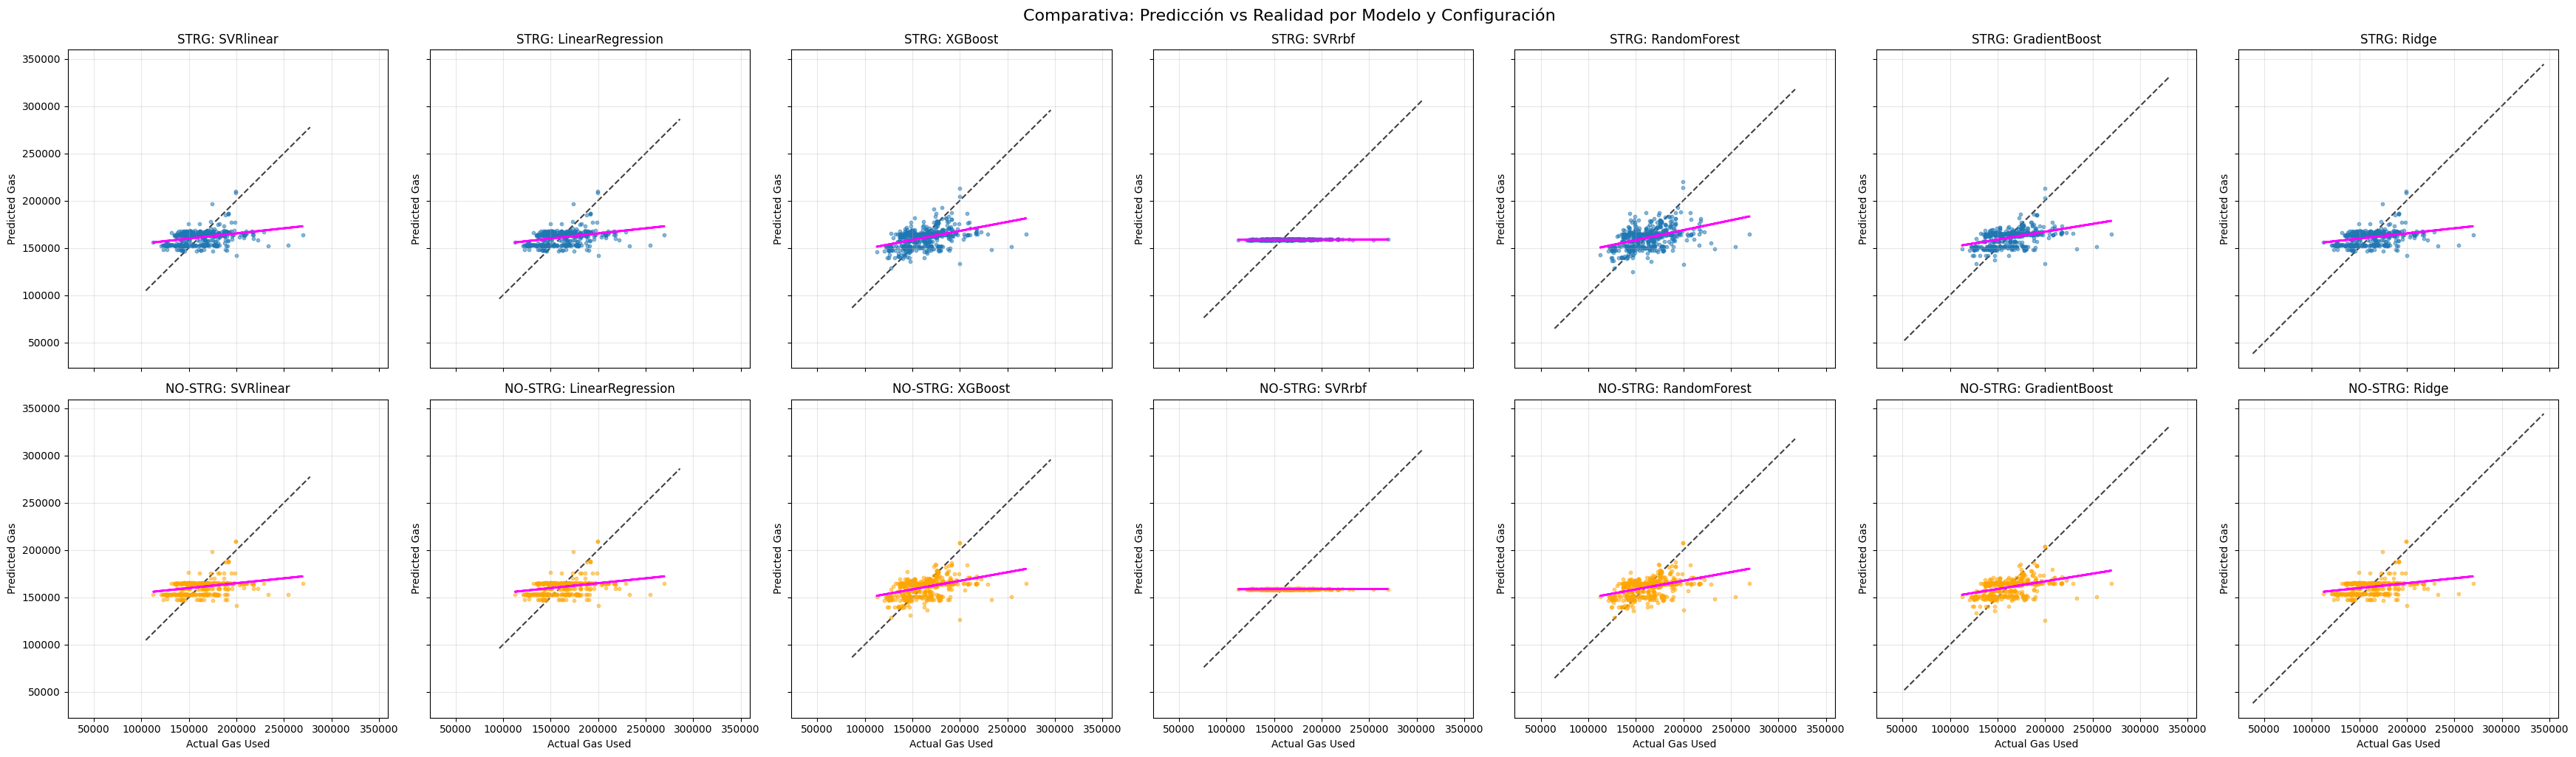

In [22]:
import numpy as np
import matplotlib.pyplot as plt

n_modelos = len(modelos_usados)
fig, axes = plt.subplots(2, n_modelos, figsize=(5 * n_modelos, 10), sharex=True, sharey=True)

if n_modelos == 1:
    axes = axes.reshape(2, 1)

for i, model in enumerate(modelos_usados):
    ax_strg = axes[0, i]
    ax_strg.scatter(y_test, strg_pred[model], alpha=0.5, s=10, label='Datos')
    
    z_s = np.polyfit(y_test, strg_pred[model], 1)
    p_s = np.poly1d(z_s)
    ax_strg.plot(y_test, p_s(y_test), color='magenta', linewidth=2, label='Tendencia')
    lims = [np.min([ax_strg.get_xlim(), ax_strg.get_ylim()]), 
            np.max([ax_strg.get_xlim(), ax_strg.get_ylim()])]
    ax_strg.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Ideal')
    
    ax_strg.set_title(f'STRG: {model}')
    ax_strg.set_ylabel('Predicted Gas')
    ax_strg.grid(True, alpha=0.3)

    ax_nostrg = axes[1, i]
    ax_nostrg.scatter(y_test, nostrg_pred[model], alpha=0.5, s=10, color='orange')
    
    z_n = np.polyfit(y_test, nostrg_pred[model], 1)
    p_n = np.poly1d(z_n)
    ax_nostrg.plot(y_test, p_n(y_test), color='magenta', linewidth=2)
    
    # Línea de identidad
    ax_nostrg.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
    
    ax_nostrg.set_title(f'NO-STRG: {model}')
    ax_nostrg.set_xlabel('Actual Gas Used')
    ax_nostrg.set_ylabel('Predicted Gas')
    ax_nostrg.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Comparativa: Predicción vs Realidad por Modelo y Configuración', fontsize=16, y=1.02)
if(save):plt.savefig(f'../memory/{carpeta}/predVsReal.pdf')
plt.show()

In [23]:
for model in modelos_usados:
    strg_pred[model]=strg_models[model].model.predict(X_test)
    nostrg_pred[model]=nostrg_models[model].model.predict(X_test_no)

In [24]:
tabla_comparativa = []
for model in modelos_usados:
    m_strg = strg_models[model]
    tabla_comparativa.append({ 'Config': 'STRG','Modelo': model,
        'MSE': m_strg.mse,'MAE': m_strg.mae,'RMSE': m_strg.rmse,'R2': m_strg.r2,'MAPE': m_strg.mape})
    
    m_nostrg = nostrg_models[model]
    tabla_comparativa.append({'Config': 'NO-STRG','Modelo': model,
        'MSE': m_nostrg.mse,'MAE': m_nostrg.mae,'RMSE': m_nostrg.rmse,'R2': m_nostrg.r2,'MAPE': m_nostrg.mape})

df_metricas = pd.DataFrame(tabla_comparativa)
df_metricas = df_metricas.sort_values(by='R2', ascending=False)#ordenamos por R2 de mejor a peor

display(df_metricas)
if(save): df_metricas.to_csv(f'../memory/{carpeta}/metricas_modelos.csv', index=False)

,Config,Modelo,MSE,MAE,RMSE,R2,MAPE
5,NO-STRG,XGBoost,3.766915e+08,14714.406258,19408.541291,0.174929,0.091056
9,NO-STRG,RandomForest,3.771310e+08,14725.267704,19419.861513,0.173967,0.091108
4,STRG,XGBoost,3.781304e+08,14783.189791,19445.576064,0.171778,0.091490
10,STRG,GradientBoost,3.828309e+08,14922.038171,19566.066212,0.161482,0.092333
11,NO-STRG,GradientBoost,3.834686e+08,14910.331153,19582.354729,0.160085,0.092260
8,STRG,RandomForest,3.967915e+08,15086.247030,19919.626963,0.130904,0.093363
12,STRG,Ridge,4.120396e+08,15745.818437,20298.757944,0.097506,0.097608
2,STRG,LinearRegression,4.120404e+08,15745.773273,20298.778507,0.097504,0.097608
0,STRG,SVRlinear,4.120409e+08,15745.651381,20298.791733,0.097503,0.097606
13,NO-STRG,Ridge,4.140455e+08,15781.501048,20348.109079,0.093112,0.097827


## Visualización de la distribución de las métricas 

### R^2

In [25]:
tipos_storage = ['no storage', 'with storage']
minSize = 10000

#### Distribución

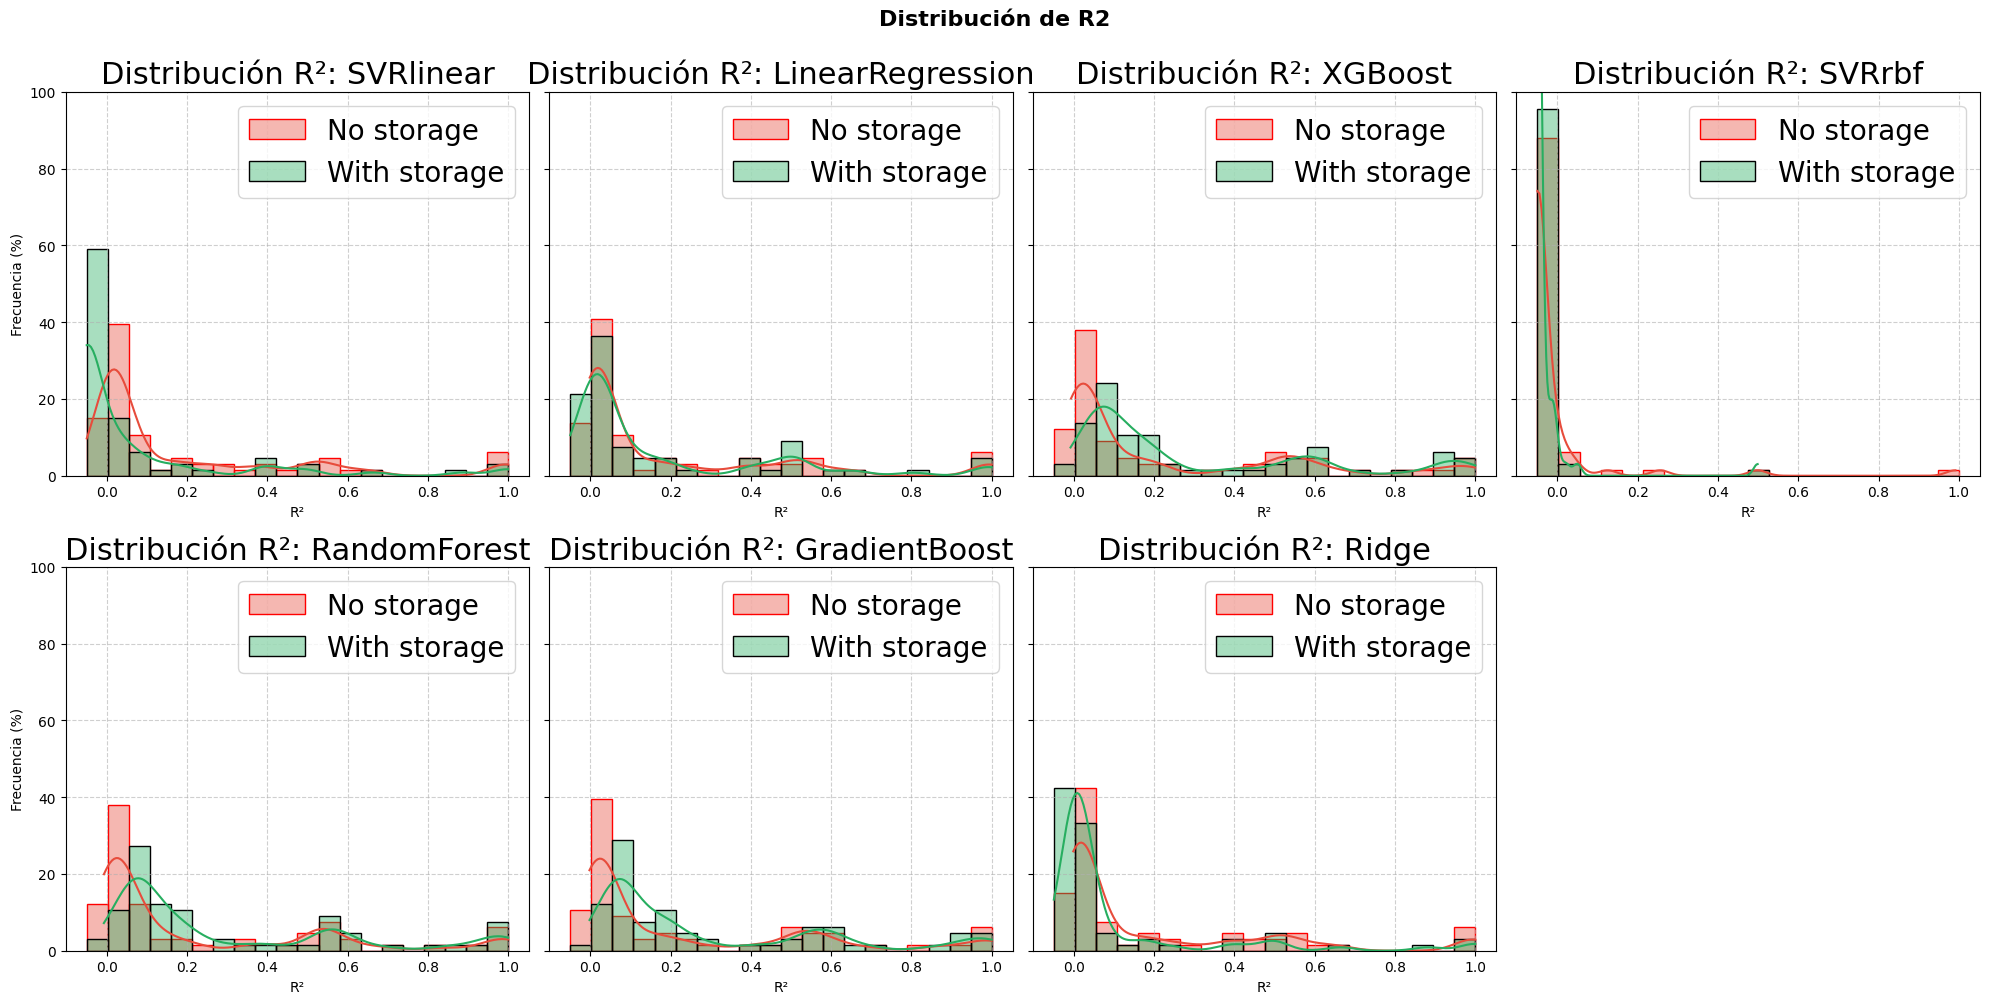

In [26]:
#R^2 -> Ver la precisión general sin que los modelos "desastrosos" arruinen la escala.
resultados = {m: {s: [] for s in tipos_storage} for m in modelos_usados}

for contract, signatures in models_dict.items():
    for signature, datos_modelo in signatures.items():
        if datos_modelo['size'] < minSize: continue
        for s_type in tipos_storage:
            for m_name in modelos_usados:
                if m_name in datos_modelo[s_type]:
                    r_cuadrado = datos_modelo[s_type][m_name].r2
                    valor_final = -0.05 if r_cuadrado < -0.05 else r_cuadrado
                    resultados[m_name][s_type].append(valor_final)

#Configurar bins
#bins = np.arange(-0.05, 1.05, 0.05) #bins homogéneos
all_flat_values = [v for s_dict in resultados.values() for lista in s_dict.values() for v in lista]
bins = np.histogram_bin_edges(all_flat_values, bins=20)#bins adaptados a los datos

# Crear la figura y los ejes
n_modelos = len(modelos_usados)
n_cols = 4
n_rows = math.ceil(n_modelos / n_cols)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5), sharey=True) # Tres gráficos en una columna
axs_flat = axs.flatten()
if n_modelos == 1: axs = [axs]

colores = {'no storage': '#e74c3c', 'with storage': '#27ae60'}
plt.rcParams.update({
    'axes.titlesize': 22,    
    'axes.labelsize': 18,    
    'legend.fontsize': 20,   
    'xtick.labelsize': 14,   
    'ytick.labelsize': 14,
    'figure.titlesize': 26
})
for i, m_name in enumerate(modelos_usados):
    ax = axs_flat[i]
    for s_type in tipos_storage:
        sns.histplot(
            resultados[m_name][s_type], 
            bins=bins, 
            kde=True, 
            ax=ax, 
            color=colores[s_type],
            label=s_type.capitalize(),
            alpha=0.4, 
            edgecolor='red' if s_type == 'no storage' else 'black',
            kde_kws={"bw_adjust": 0.35},
            stat="percent",
            common_norm=False,
        )
    ax.set_ylim(0, 100)
    ax.set_title(f'Distribución R²: {m_name}')
    ax.set_xlabel('R²')
    ax.set_ylabel('Frecuencia (%)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

for j in range(i + 1, len(axs_flat)):
    axs_flat[j].axis('off')
    
fig.suptitle(f'Distribución de R2', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
if(save): plt.savefig(f'../memory/{carpeta}/resultados_r2.pdf')
plt.show()

#### Varianza

In [27]:
resumen_metricas = []
for m_name in modelos_usados:
    for s_type in tipos_storage:
        # Usamos las listas de R2 que ya recolectamos en el paso anterior
        datos = resultados[m_name][s_type]
        
        if datos:
            r2_medio = np.mean(datos)
            r2_std = np.std(datos)
            
            resumen_metricas.append({
                'Modelo': m_name,
                'Storage': s_type,
                'R2_Medio': r2_medio,
                'R2_Std': r2_std
            })

df_resumen = pd.DataFrame(resumen_metricas)

df_resumen = df_resumen.sort_values(by='R2_Medio', ascending=False)
if(save): df_resumen.to_csv(f'../memory/{carpeta}/r2medio.csv', index=False)
print(df_resumen)

              Modelo       Storage  R2_Medio    R2_Std
5            XGBoost  with storage  0.296678  0.304972
9       RandomForest  with storage  0.296328  0.306415
11     GradientBoost  with storage  0.293358  0.297803
10     GradientBoost    no storage  0.232752  0.304006
4            XGBoost    no storage  0.231384  0.302311
8       RandomForest    no storage  0.229676  0.306205
2   LinearRegression    no storage  0.189991  0.278074
12             Ridge    no storage  0.189195  0.278316
0          SVRlinear    no storage  0.185245  0.276487
3   LinearRegression  with storage  0.180257  0.270554
13             Ridge  with storage  0.109669  0.235403
1          SVRlinear  with storage  0.078418  0.248161
6             SVRrbf    no storage -0.009491  0.147618
7             SVRrbf  with storage -0.034544  0.068632


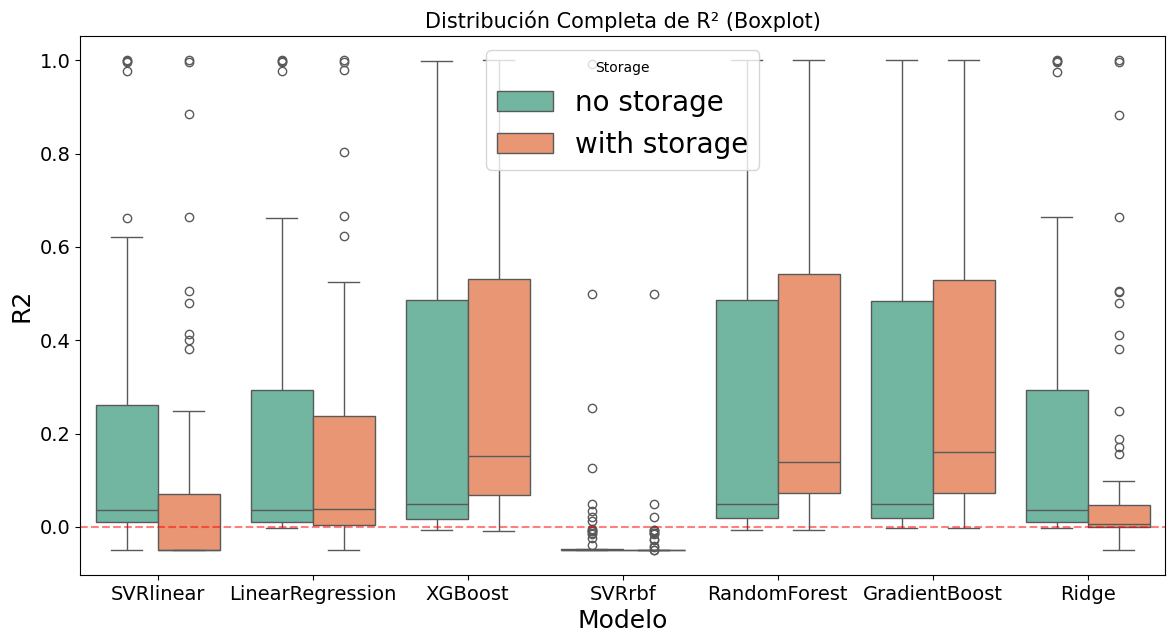

In [28]:
datos_plot = []
for m_name in modelos_usados:
    for s_type in tipos_storage:
        for val in resultados[m_name][s_type]:
            datos_plot.append({'Modelo': m_name, 'Storage': s_type, 'R2': val})

df_plot = pd.DataFrame(datos_plot)

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_plot, x='Modelo', y='R2', hue='Storage', palette='Set2')
plt.title('Distribución Completa de R² (Boxplot)', fontsize=15)
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Línea en 0 para ver quién empeora la media
if(save): plt.savefig(f'../memory/{carpeta}/distrib_r2.pdf')
plt.show()

In [29]:
filas_comparativa = []

for contract, signatures in models_dict.items():
    for signature, datos_modelo in signatures.items():
        # Extraemos el tamaño (cantidad de datos)
        n_datos = datos_modelo.get('size', 0)
        
        # Calculamos un R2 promedio de todos los modelos usados para esa firma específica
        # (Puedes filtrar solo por un modelo si prefieres, ej: 'GradientBoost')
        r2_lista = []
        for m_name in modelos_usados:
            # Promediamos entre 'no storage' y 'with storage' para tener una métrica general por firma
            r2_no = datos_modelo['no storage'][m_name].r2
            r2_with = datos_modelo['with storage'][m_name].r2
            r2_lista.extend([r2_no, r2_with])
        
        r2_promedio_firma = np.mean(r2_lista)
        
        filas_comparativa.append({
            'Contrato': contract,
            'Signature': signature,
            'Tamaño_Datos': n_datos,
            'R2_Promedio': r2_promedio_firma
        })

df_contratos = pd.DataFrame(filas_comparativa)

# Vemos los 10 mejores o una muestra
print(df_contratos.sort_values(by='Tamaño_Datos', ascending=False).head(10))
if(save): df_contratos.to_csv(f'../memory/{carpeta}/r2medioporTamañoDatos.csv', index=False)

                                      Contrato   Signature  Tamaño_Datos  \
61  0xdac17f958d2ee523a2206206994597c13d831ec7  0xa9059cbb        199997   
36  0x881d40237659c251811cec9c364ef91dc08d300c  0x5f575529        199994   
42  0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48  0xa9059cbb        199993   
59  0xdac17f958d2ee523a2206206994597c13d831ec7  0x095ea7b3        184187   
41  0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48  0x095ea7b3        116532   
53  0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2  0x2e1a7d4d        114107   
39  0x95ad61b0a150d79219dcf64e1e6cc01f0b64c4ce  0xa9059cbb        111937   
60  0xdac17f958d2ee523a2206206994597c13d831ec7  0x23b872dd        108104   
52  0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2  0xd0e30db0        100652   
25  0x514910771af9ca656af840dff83e8264ecf986ca  0xa9059cbb         79902   

    R2_Promedio  
61     0.178114  
36     0.460355  
42    -2.170694  
59    -2.519416  
41    -2.936016  
53    -0.036222  
39    -1.196680  
60    -5.794847  
5

### MAE

In [30]:
limite_mae = 10000

### MAE >10k

#### Distribución

In [31]:
modelos_usados = ['LinearRegression',
 'SVRrbf',
 'SVRlinear',
 'Ridge',
 'XGBoost',
 'RandomForest',    
 'GradientBoost',]

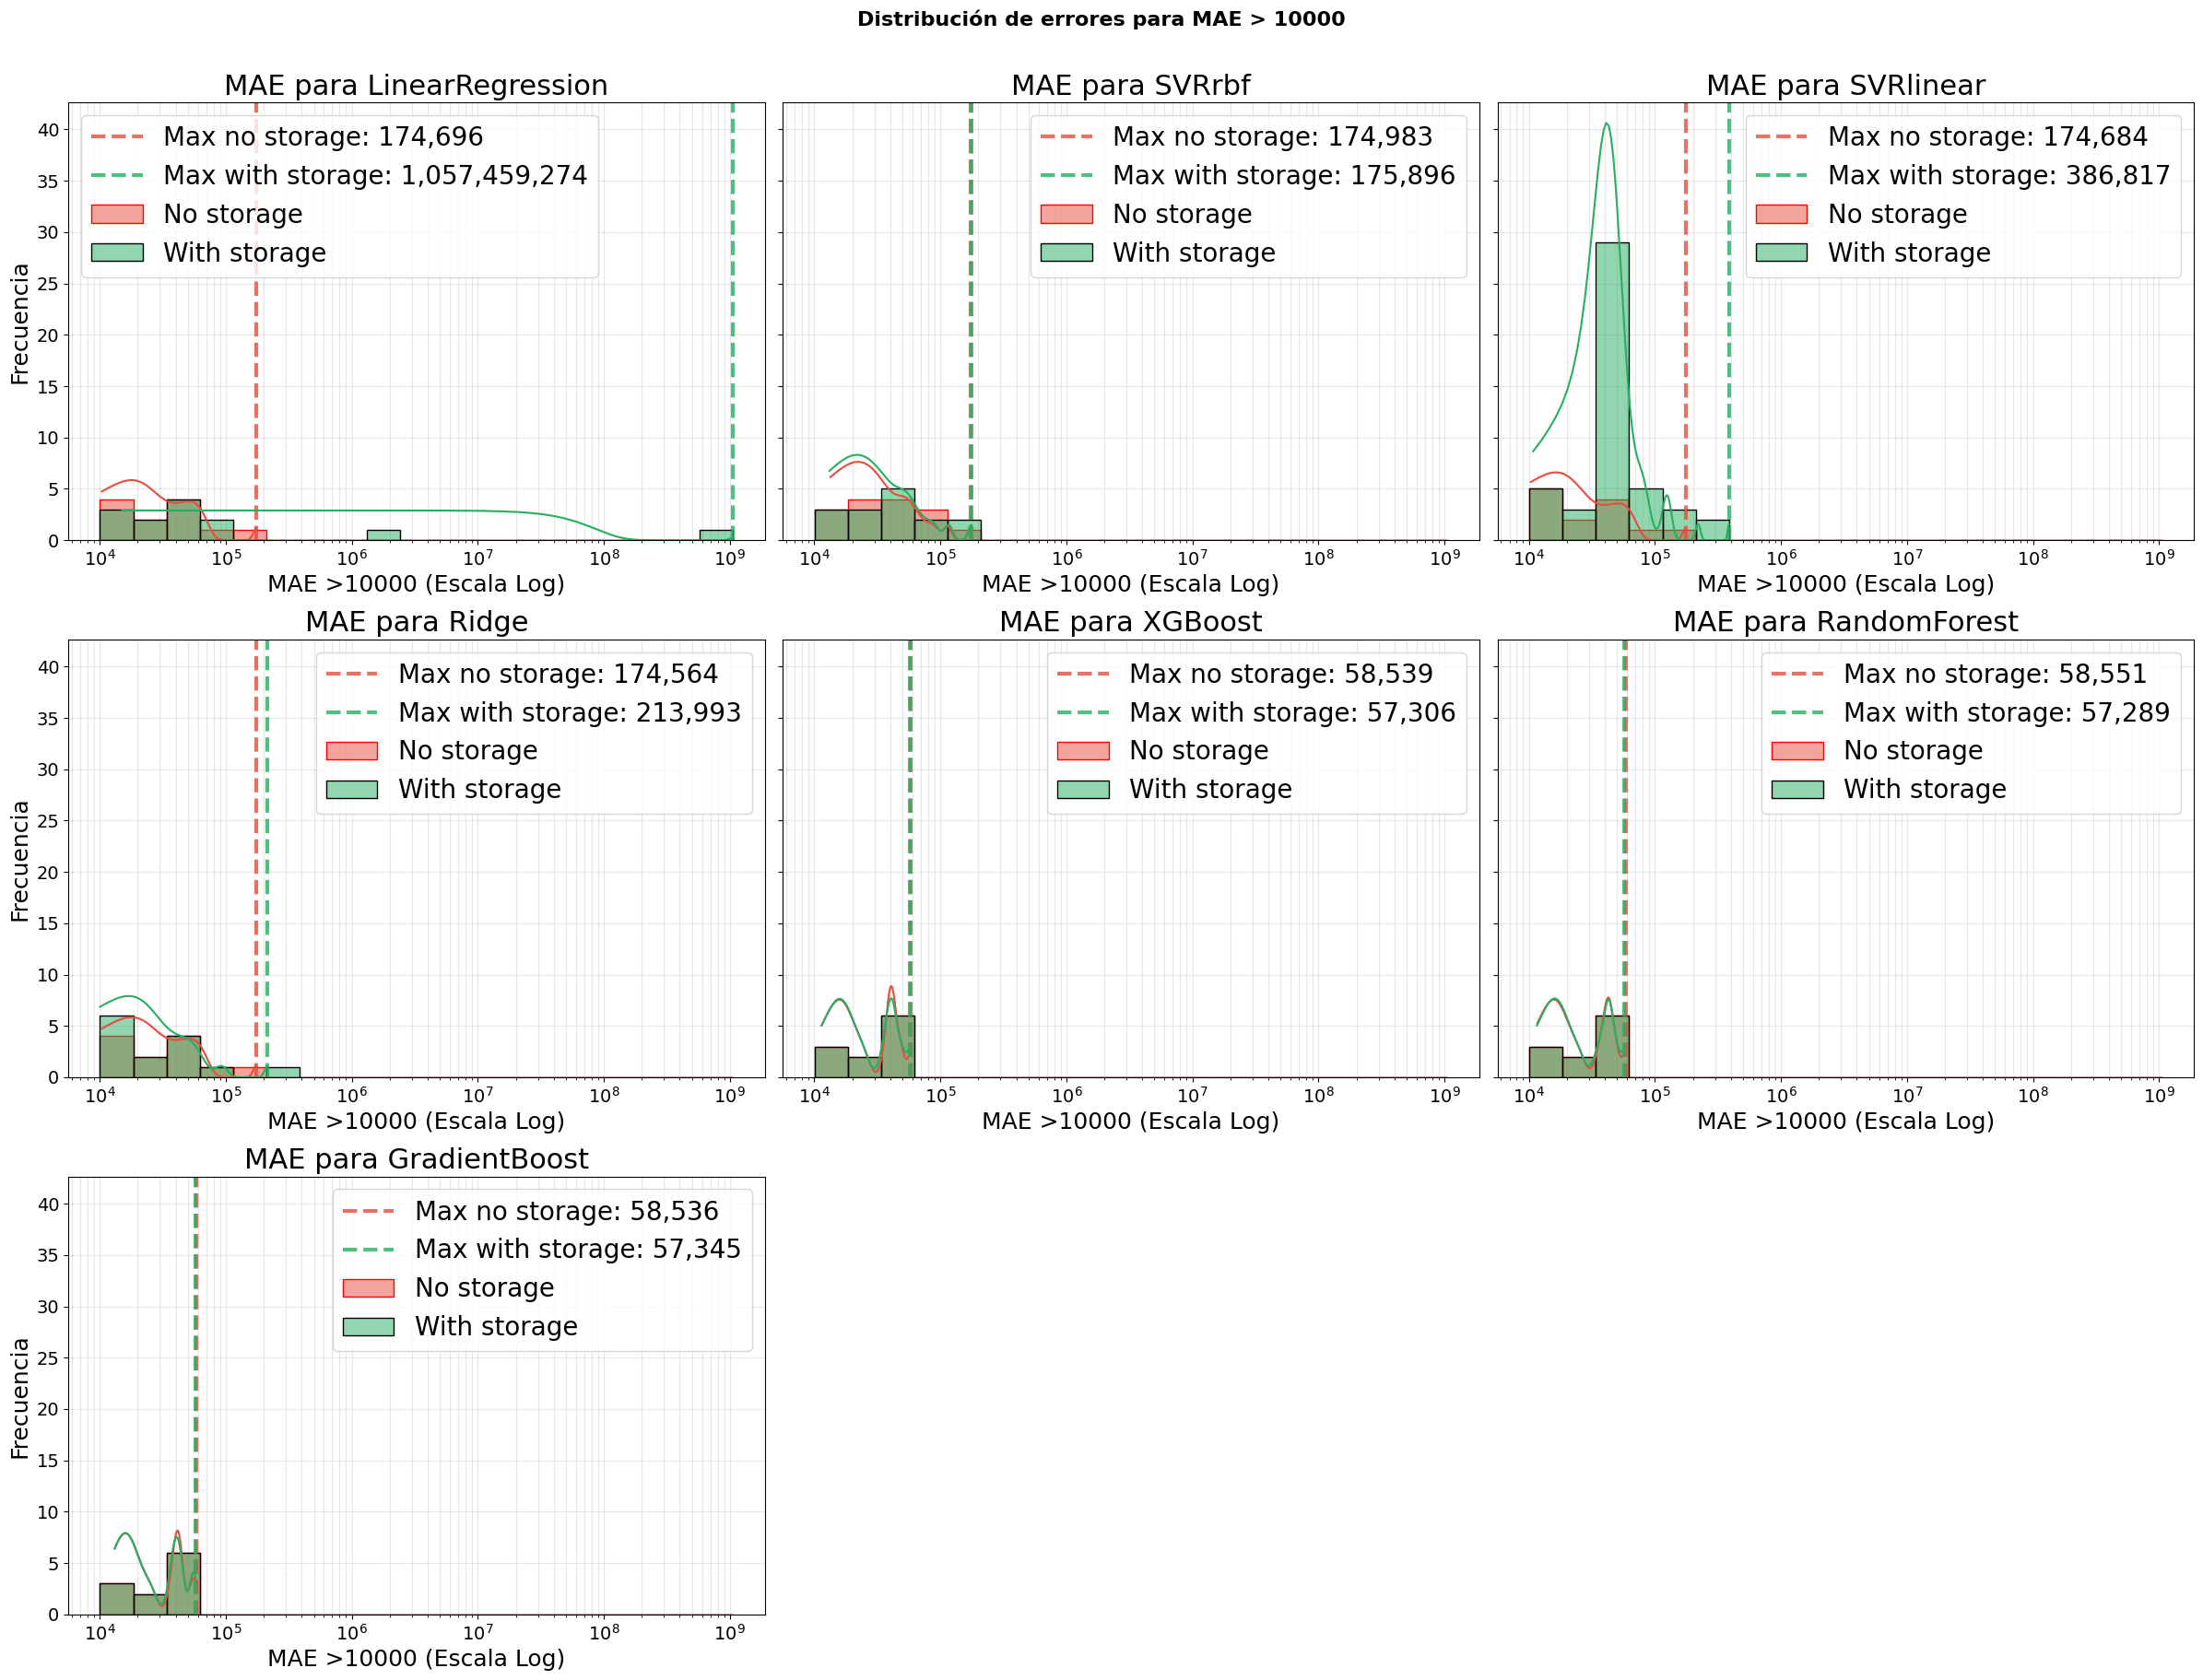

In [32]:
#MAE > 10k ->
mae_resultados = {m: {s: [] for s in tipos_storage} for m in modelos_usados}

for contract, signatures in models_dict.items():
    for signature, datos_modelo in signatures.items():
        if datos_modelo['size'] < minSize: continue
        for s_type in tipos_storage:
            for m_name in modelos_usados:
                if m_name in datos_modelo[s_type]:
                    valor_mae = datos_modelo[s_type][m_name].mae
                    if valor_mae > limite_mae:
                        mae_resultados[m_name][s_type].append(valor_mae)


#Configurar bins
all_mae_values = [v for s_dict in mae_resultados.values() for lista in s_dict.values() for v in lista]
if all_mae_values:
    min_val = min(all_mae_values)
    max_val = max(all_mae_values)
    bins = np.logspace(np.log10(min_val), np.log10(max_val), 20)#bins logaritmicos
else:
    bins = 20 

# Crear la figura y los ejes
n_modelos = len(modelos_usados)
n_cols = 3 if n_modelos > 1 else 1 # Dos gráficos en una columna
n_rows = math.ceil(n_modelos / n_cols)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 6), sharey=True)
axs_flat = axs.flatten() if n_modelos > 1 else [axs]

colores = {'no storage': '#e74c3c', 'with storage': '#27ae60'}  
plt.rcParams.update({
    'axes.titlesize': 22,    
    'axes.labelsize': 18,    
    'legend.fontsize': 20,   
    'xtick.labelsize': 14,   
    'ytick.labelsize': 14,
    'figure.titlesize': 26
})

for i, m_name in enumerate(modelos_usados):
    ax = axs_flat[i]
    
    for s_type in tipos_storage:
        datos_plot = mae_resultados[m_name][s_type]
        if datos_plot:
            sns.histplot(
                datos_plot, 
                ax=ax, 
                kde=True, 
                color=colores[s_type],
                label=s_type.capitalize(),
                alpha=0.5, 
                edgecolor='red' if s_type == 'no storage' else 'black',
                bins=bins,
                kde_kws={"bw_adjust": 0.35},
                linewidth=1,
            )
            peor_valor_storage = max(datos_plot)
            color_linea = colores[s_type]
            ax.axvline(
                peor_valor_storage, 
                color=color_linea, 
                linestyle='--', 
                linewidth=3,
                alpha=0.8,
                label=f'Max {s_type}: {peor_valor_storage:,.0f}'
            )
   
    ax.set_title(f'MAE para {m_name}')
    ax.set_xlabel(f'MAE >{limite_mae} (Escala Log)')
    ax.set_ylabel('Frecuencia')
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, which="both", ls="-", alpha=0.3)
    ax.set_axisbelow(True)

# Ocultar ejes sobrantes si los hay
for j in range(i + 1, len(axs_flat)):
    axs_flat[j].axis('off')

fig.suptitle(f'Distribución de errores para MAE > {limite_mae}', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
if(save): plt.savefig(f'../memory/{carpeta}/mae_mayor_10000.pdf')
plt.show()

In [33]:
for model in modelos_usados:
    for tipo in tipos_storage:
        orden = sorted(mae_resultados[model][tipo], reverse=True)
        print( f'{model} - { tipo} : { orden[:5]}')

LinearRegression - no storage : [174695.77297203784, 67432.63702466794, 58533.38667491121, 54616.1257470827, 45110.999805323605]
LinearRegression - with storage : [1057459274.0609446, 2399054.277818438, 96364.08050166802, 91760.51657836605, 59217.14080288]
SVRrbf - no storage : [174982.73191416357, 114235.40871271373, 87631.19153728687, 70030.64068152159, 58039.53104047048]
SVRrbf - with storage : [175896.38581932493, 116089.72870818853, 87647.64921287716, 70521.88461124917, 58041.59765714198]
SVRlinear - no storage : [174684.44756892155, 67623.27180454321, 58541.25341556448, 54568.77530536866, 45104.08299974723]
SVRlinear - with storage : [386817.1690978834, 219858.61046282598, 129402.32451682366, 123870.23187895647, 120176.61316354091]
Ridge - no storage : [174563.63401275093, 67641.60946830992, 58651.78752824351, 54399.01077707171, 45112.112927428076]
Ridge - with storage : [213992.63091667026, 92087.61446512704, 59650.990017275624, 54027.82910087773, 44962.18405814643]
XGBoost - no

#### Varianza 

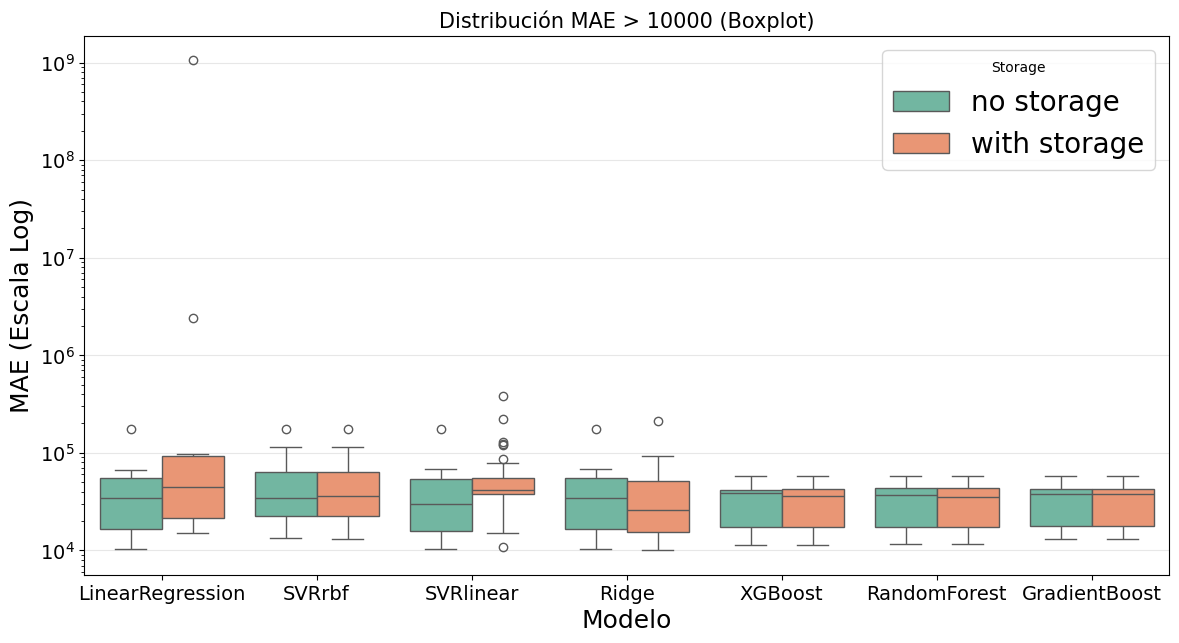

In [34]:
mae_resultados = {m: {s: [] for s in tipos_storage} for m in modelos_usados}

for contract, signatures in models_dict.items():
    for signature, datos_modelo in signatures.items():
        if datos_modelo['size'] < minSize:
            continue

        for s_type in tipos_storage:
            for m_name in modelos_usados:
                if m_name in datos_modelo[s_type]:
                    valor_mae = datos_modelo[s_type][m_name].mae

                    if valor_mae > limite_mae:
                        mae_resultados[m_name][s_type].append(valor_mae)
datos_plot = []

for m_name in modelos_usados:
    for s_type in tipos_storage:
        for val in mae_resultados[m_name][s_type]:
            datos_plot.append({
                'Modelo': m_name,
                'Storage': s_type,
                'MAE': val
            })

df_plot_mae_mayor = pd.DataFrame(datos_plot)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_plot_mae_mayor,
    x='Modelo',
    y='MAE',
    hue='Storage',
    palette='Set2'
)

plt.yscale('log')
plt.title(f'Distribución MAE > {limite_mae} (Boxplot)', fontsize=15)
plt.xlabel('Modelo')
plt.ylabel('MAE (Escala Log)')
plt.grid(True, axis='y', alpha=0.3)

if save:
    plt.savefig(f'../memory/{carpeta}/boxplot_mae_mayor_{limite_mae}.pdf')

plt.show()

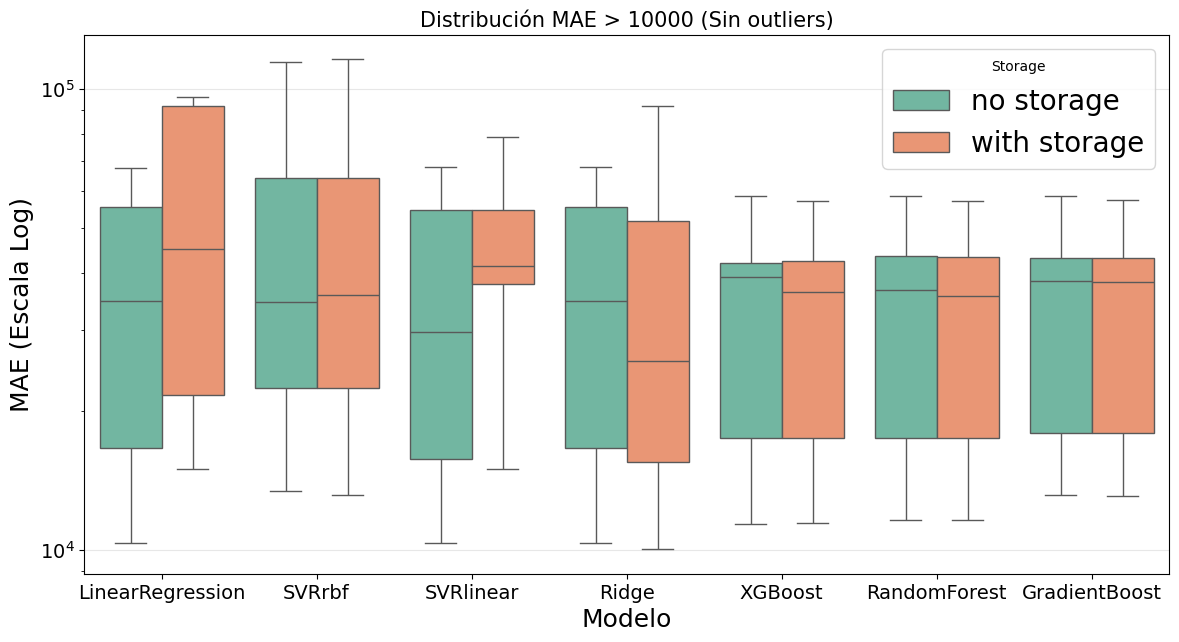

In [35]:
df_plot_mae_mayor = pd.DataFrame(datos_plot)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_plot_mae_mayor,
    x='Modelo',
    y='MAE',
    hue='Storage',
    palette='Set2',
    showfliers=False
)

plt.yscale('log')
plt.title(f'Distribución MAE > {limite_mae} (Sin outliers)', fontsize=15)
plt.xlabel('Modelo')
plt.ylabel('MAE (Escala Log)')
plt.grid(True, axis='y', alpha=0.3)

if save:
    plt.savefig(f'../memory/{carpeta}/boxplot_mae_mayor2_{limite_mae}.pdf')

plt.show()

In [36]:
filas_mae_malos = []

for contract, signatures in models_dict.items():
    for signature, datos_modelo in signatures.items():

        n_datos = datos_modelo.get('size', 0)

        mae_lista = []

        for m_name in modelos_usados:
            if m_name in datos_modelo['no storage'] and m_name in datos_modelo['with storage']:
                
                mae_no = datos_modelo['no storage'][m_name].mae
                mae_with = datos_modelo['with storage'][m_name].mae
                
                mae_lista.extend([mae_no, mae_with])

        if mae_lista:
            mae_promedio = np.mean(mae_lista)

            if mae_promedio > limite_mae:
                filas_mae_malos.append({
                    'Contrato': contract,
                    'Signature': signature,
                    'Tamaño_Datos': n_datos,
                    'MAE_Promedio': mae_promedio
                })

df_mae_malos = pd.DataFrame(filas_mae_malos)

print("🔻 Peores casos (MAE alto):")
print(df_mae_malos.sort_values(by='MAE_Promedio', ascending=False).head(10))

if save:
    df_mae_malos.to_csv(f'../memory/{carpeta}/mae_mayor.csv', index=False)

🔻 Peores casos (MAE alto):
                                      Contrato   Signature  Tamaño_Datos  \
30  0xf411903cbc70a74d22900a5de66a2dda66507255  0xa9059cbb         17500   
26  0xaea46a60368a7bd060eec7df8cba43b7ef41ad85  0xa9059cbb         13646   
28  0xc36442b4a4522e871399cd717abdd847ab11fe88  0xac9650d8         38278   
4   0x1111111254eeb25477b68fb85ed929f73a960582  0x12aa3caf         75424   
21  0x7fc66500c84a76ad7e9c93437bfc5ac33e2ddae9  0xa9059cbb         14590   
6   0x1111111254fb6c44bac0bed2854e76f90643097d  0x7c025200         19981   
17  0x6131b5fae19ea4f9d964eac0408e4408b66337b5  0xe21fd0e9         32431   
16  0x6131b5fae19ea4f9d964eac0408e4408b66337b5  0x8af033fb         15666   
22  0x881d40237659c251811cec9c364ef91dc08d300c  0x5f575529        199994   
3   0x1111111254eeb25477b68fb85ed929f73a960582  0x0502b1c5         74644   

    MAE_Promedio  
30  7.554518e+07  
26  1.820661e+05  
28  1.285035e+05  
4   7.750422e+04  
21  6.178417e+04  
6   5.124355e+04  
17 

### MAE <=10k

#### Distribución

In [37]:
modelos_usados = ['LinearRegression',
 'SVRrbf',
 'SVRlinear',
 'Ridge',
 'XGBoost',
 'GradientBoost',
 'RandomForest']

<>:57: SyntaxWarning: invalid escape sequence '\l'
<>:57: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_525902/3711632437.py:57: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'Distribución MAE $\leq$ 10k: {m_name}')


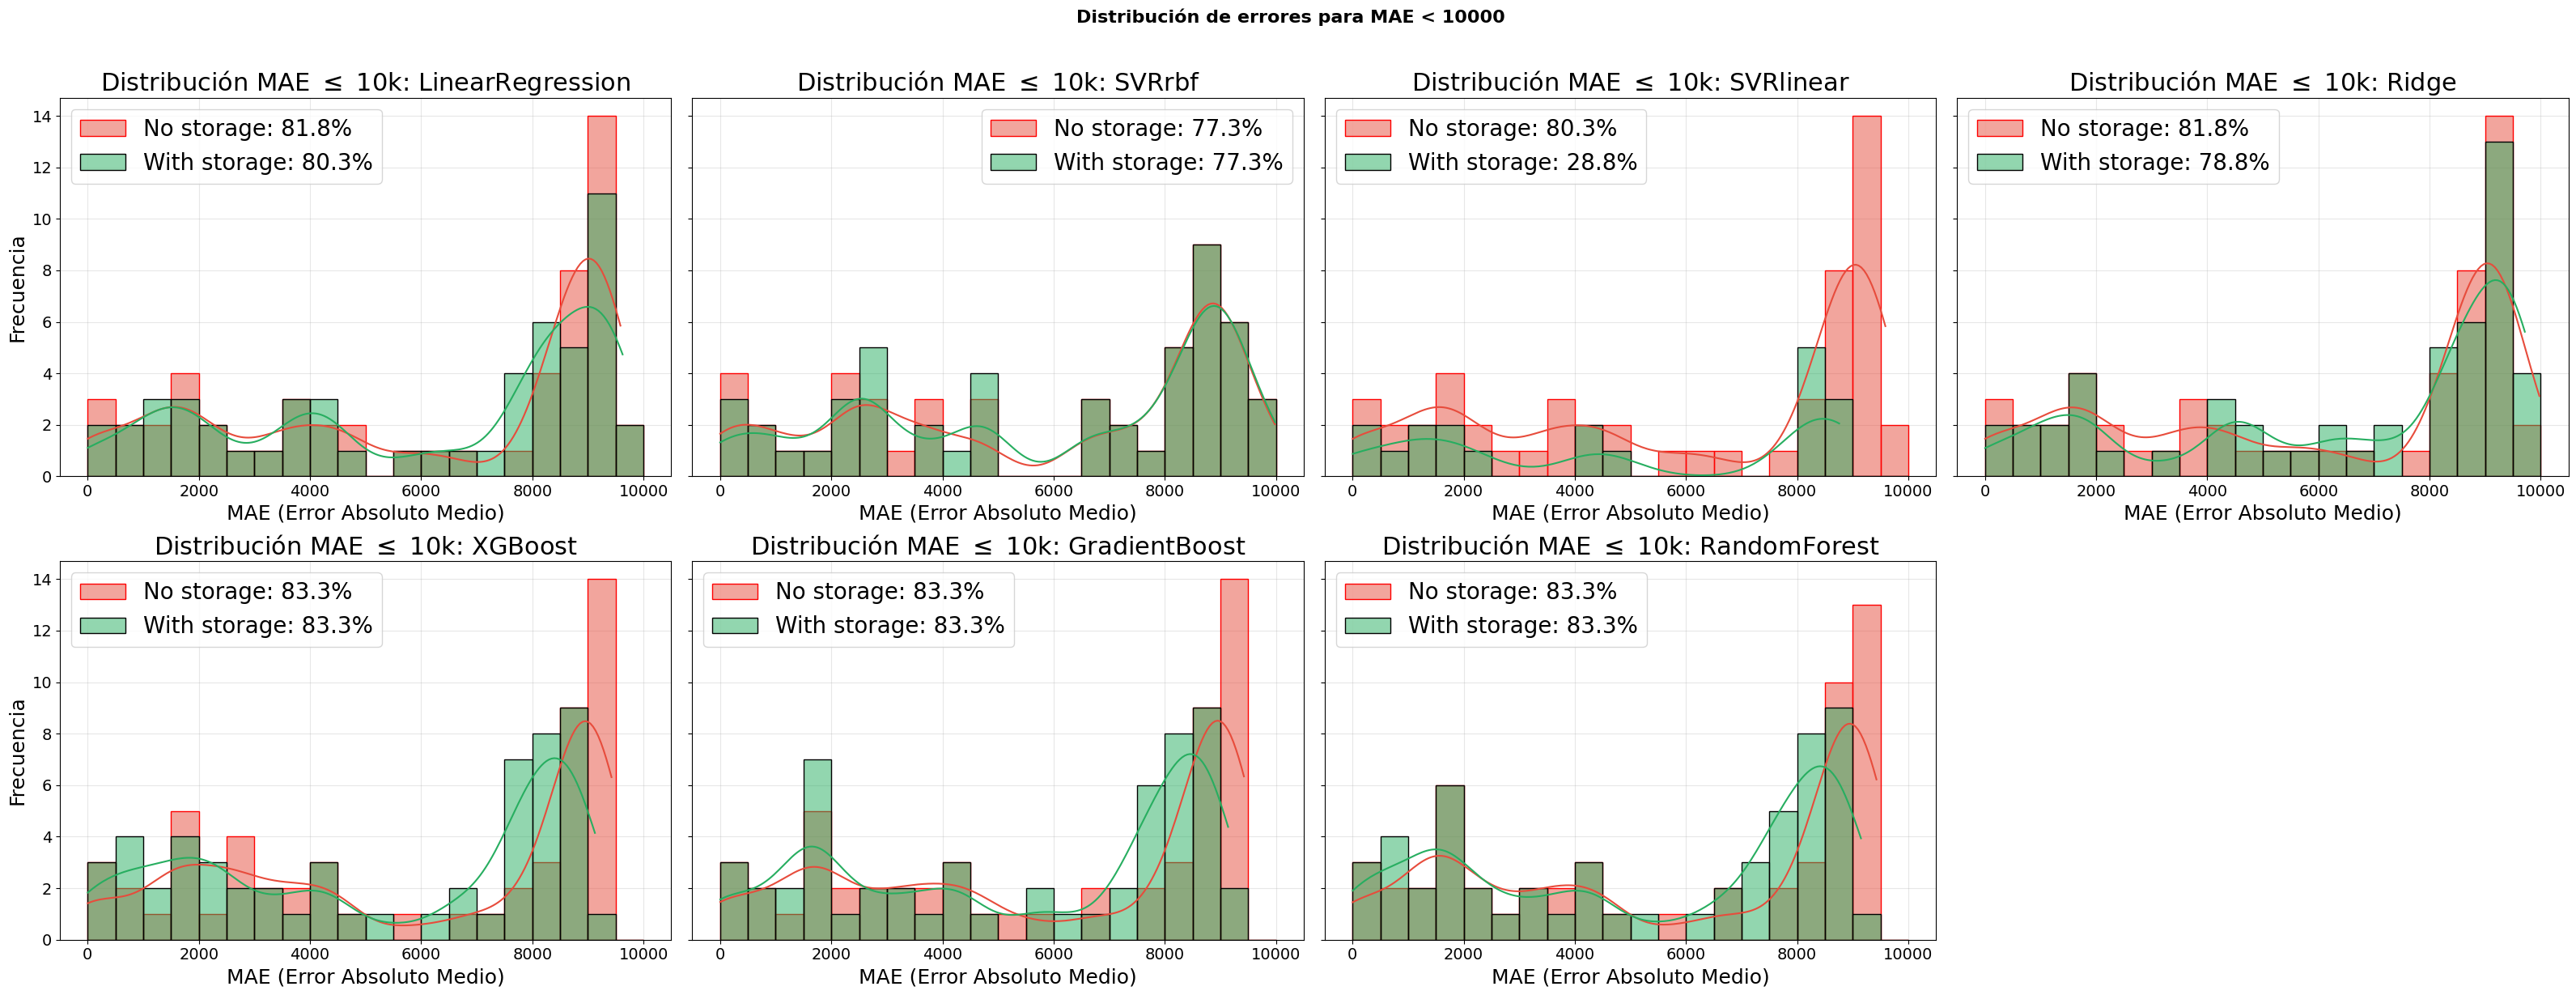

In [38]:
#MAE <= 10k -> Analizar los casos donde el modelo es más preciso
mae_precisos = {m: {s: [] for s in tipos_storage} for m in modelos_usados}
conteo_total = {m: {s: 0 for s in tipos_storage} for m in modelos_usados}

for contract, signatures in models_dict.items():
    for signature, datos_modelo in signatures.items():
        if datos_modelo['size'] < minSize: continue #10000
        for s_type in tipos_storage:
            for m_name in modelos_usados:
                if m_name in datos_modelo[s_type]:
                    conteo_total[m_name][s_type] += 1
                    val_mae = datos_modelo[s_type][m_name].mae
                    if val_mae <= limite_mae:
                        mae_precisos[m_name][s_type].append(val_mae)
                        
#Configurar bins
ancho_bin = 500
bins_fijos = np.arange(0, limite_mae + 1, ancho_bin)

n_modelos = len(modelos_usados)
n_cols = 4 # Dos gráficos en una columna
n_rows = math.ceil(n_modelos / n_cols)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 6), sharey=True)
axs_flat = axs.flatten() if n_modelos > 1 else [axs]

colores = {'no storage': '#e74c3c', 'with storage': '#27ae60'}
plt.rcParams.update({
    'axes.titlesize': 22,    
    'axes.labelsize': 18,    
    'legend.fontsize': 20,   
    'xtick.labelsize': 14,   
    'ytick.labelsize': 14,
    'figure.titlesize': 26
})

for i, m_name in enumerate(modelos_usados):
    ax = axs_flat[i]
    
    for s_type in tipos_storage:
        datos_plot = mae_precisos[m_name][s_type]
        total_casos = conteo_total[m_name][s_type]
        if datos_plot:
            n_muestras = len(datos_plot)
            perc = (n_muestras / total_casos) * 100
            sns.histplot(
                datos_plot, 
                ax=ax, 
                kde=True, 
                color=colores[s_type],
                label=f'{s_type.capitalize()}: {perc:.1f}%',
                alpha=0.5, 
                edgecolor='red' if s_type == 'no storage' else 'black',
                bins=bins_fijos,
                kde_kws={"bw_adjust": 0.35}
            )
    
    ax.set_title(f'Distribución MAE $\leq$ 10k: {m_name}')
    ax.set_xlabel('MAE (Error Absoluto Medio)')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

for j in range(i + 1, len(axs_flat)):
    axs_flat[j].axis('off')

fig.suptitle(f'Distribución de errores para MAE < {limite_mae}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
if(save): plt.savefig(f'../memory/{carpeta}/mae_menor_10000.pdf')
plt.show()

#### Varianza

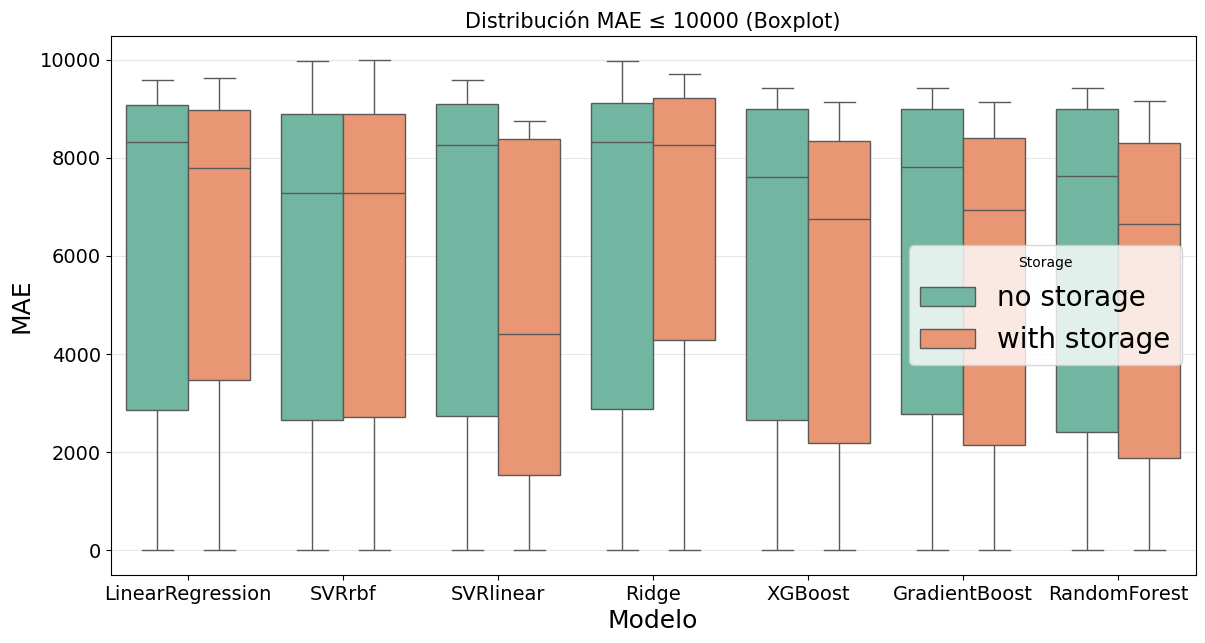

In [39]:
# MAE <= limite_mae -> BOXPLOT

mae_precisos = {m: {s: [] for s in tipos_storage} for m in modelos_usados}

for contract, signatures in models_dict.items():
    for signature, datos_modelo in signatures.items():
        if datos_modelo['size'] < minSize:
            continue

        for s_type in tipos_storage:
            for m_name in modelos_usados:
                if m_name in datos_modelo[s_type]:
                    valor_mae = datos_modelo[s_type][m_name].mae

                    if valor_mae <= limite_mae:
                        mae_precisos[m_name][s_type].append(valor_mae)


datos_plot = []

for m_name in modelos_usados:
    for s_type in tipos_storage:
        for val in mae_precisos[m_name][s_type]:
            datos_plot.append({
                'Modelo': m_name,
                'Storage': s_type,
                'MAE': val
            })

df_plot_mae_menor = pd.DataFrame(datos_plot)

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_plot_mae_menor,
    x='Modelo',
    y='MAE',
    hue='Storage',
    palette='Set2'
)

plt.title(f'Distribución MAE ≤ {limite_mae} (Boxplot)', fontsize=15)
plt.xlabel('Modelo')
plt.ylabel('MAE')
plt.grid(True, axis='y', alpha=0.3)

if save:
    plt.savefig(f'../memory/{carpeta}/boxplot_mae_menor_{limite_mae}.pdf')

plt.show()

## Dirección del error

In [40]:
minSize = 10000

In [41]:
filas_error = []
for contract, signatures in models_dict.items():
    for signature, datos_modelo in signatures.items():

        if datos_modelo["size"] < minSize:
            continue
        y_test = datos_modelo["y_test"]
        X_test = datos_modelo["X_test"]
        if new and len(new)>0:
            y_test2 = datos_modelo["y_test2"]
            X_test2 = datos_modelo["X_test2"]

        storage_cols = datos_modelo.get("storage info", [])
        X_test_no = X_test.drop(columns=storage_cols, errors="ignore")
        if new and len(new)>0:
            X_test_no2 = X_test2.drop(columns=storage_cols, errors="ignore")

        for s_type in ["with storage", "no storage"]:
            if s_type not in datos_modelo:continue
            for m_name in modelos_usados:
                if m_name not in datos_modelo[s_type]:continue
                modelo = datos_modelo[s_type][m_name].model
                X_eval = X_test if s_type == "with storage" else X_test_no
                if m_name in new:
                     X_eval = X_test2 if s_type == "with storage" else X_test_no2
                try:
                    y_pred = modelo.predict(X_eval)
                except Exception as e:
                    print(f"Error en {m_name} - {s_type}: {e}")
                    continue
                errores = np.array(y_pred) - np.array(y_test)
                for error in errores:
                    filas_error.append({
                        "Modelo": m_name,
                        "Storage": s_type,
                        "Error": error
                    })

df_errores = pd.DataFrame(filas_error)
if save:
    df_errores.to_csv(f'../memory/{carpeta}/difs.csv', index=False)

print(df_errores.head())
print("Filas:", len(df_errores))

             Modelo       Storage         Error
0  LinearRegression  with storage  9.021259e+06
1  LinearRegression  with storage  9.116034e+06
2  LinearRegression  with storage  5.327404e+06
3  LinearRegression  with storage  7.126321e+06
4  LinearRegression  with storage -4.021532e+04
Filas: 462000


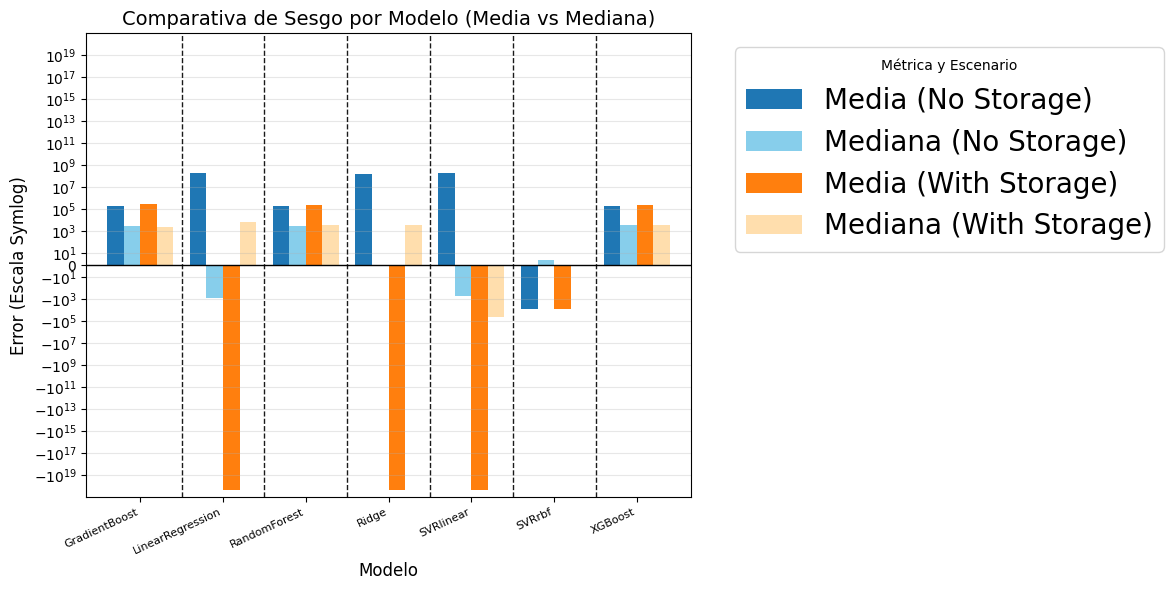

In [42]:
df_bias_plot = (
    df_errores
    .groupby(["Modelo", "Storage"])
    .agg(
        Bias_mediano=("Error", "median"),
        Bias_medio=("Error", "mean")
    )
    .reset_index()
)

tabla_plot = df_bias_plot.pivot(
    index="Modelo",
    columns="Storage",
    values=["Bias_medio", "Bias_mediano"]
)

orden_columnas = [
    ('Bias_medio', 'no storage'),
    ('Bias_mediano', 'no storage'),
    ('Bias_medio', 'with storage'),
    ('Bias_mediano', 'with storage')
]
tabla_plot = tabla_plot[orden_columnas]


colores = [
    '#1f77b4', 'skyblue',  # No storage (Media, Mediana)
    '#ff7f0e', 'navajowhite' # With storage (Media, Mediana)
]

plt.rcParams.update({
    'figure.titlesize': 16,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10
})

ax = tabla_plot.plot(kind="bar", figsize=(12, 6), color=colores, width=0.8)

etiquetas_leyenda = [
    "Media (No Storage)", "Mediana (No Storage)",
    "Media (With Storage)", "Mediana (With Storage)"
]
ax.legend(etiquetas_leyenda, title="Métrica y Escenario", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_yscale('symlog', linthresh=10)
ax.set_ylim(-1e21, 1e21) 
plt.axhline(0, color='black', linewidth=1)

plt.title("Comparativa de Sesgo por Modelo (Media vs Mediana)")
plt.ylabel("Error (Escala Symlog)")
plt.xlabel("Modelo")
plt.xticks(rotation=25, ha='right')
plt.grid(axis="y", alpha=0.3)

for i in range(len(tabla_plot) - 1):
    ax.axvline(x=i + 0.5, color='black', linestyle='--', alpha=0.9, linewidth=1)

plt.tight_layout()
plt.show()

In [43]:
df_bias_plot = (
    df_errores
    .groupby(["Modelo", "Storage"])
    .agg(
        Bias_mediano=("Error", "median"),
        Bias_medio=("Error", "mean")
    )
    .reset_index()
)

tabla_final = df_bias_plot.pivot(
    index="Modelo",
    columns="Storage",
    values=["Bias_medio", "Bias_mediano"]
)

orden_columnas = [
    ('Bias_medio', 'no storage'),
    ('Bias_mediano', 'no storage'),
    ('Bias_medio', 'with storage'),
    ('Bias_mediano', 'with storage')
]
tabla_final = tabla_final[orden_columnas]

pd.options.display.float_format = '{:,.2f}'.format

display(tabla_final)

,Bias_medio,Bias_mediano,Bias_medio,Bias_mediano
Storage,no storage,no storage,with storage,with storage
Modelo,,,,
GradientBoost,"201,953.82","2,615.45","276,971.62","2,318.45"
LinearRegression,"174,006,013.34",-800.38,"-246,808,489,547,228,708,864.00","6,112.90"
RandomForest,"203,014.42","2,900.42","243,232.71","3,575.67"
Ridge,"173,517,760.66",-0.96,"-233,034,191,666,424,643,584.00","3,541.12"
SVRlinear,"174,471,892.30",-515.48,"-246,785,171,136,620,331,008.00","-40,106.00"
SVRrbf,"-6,948.85",4.64,"-6,885.50",0.10
XGBoost,"184,442.89","3,304.38","253,343.93","3,219.39"


## Ideal Model

In [24]:
# Configuración global del criterio de selección
# Opciones: 'mae' o 'r2'
METRICA_OBJETIVO = 'mae' 

def es_mejor(actual, previo, metrica):
    """Determina si el valor actual es mejor que el previo según la métrica."""
    if previo is None: return True
    if metrica == 'r2':
        return actual > previo
    else: # mae
        return actual < previo

peor_valor = -float('inf') if METRICA_OBJETIVO == 'r2' else float('inf')

### Separando por Storage Types

In [80]:
#Modelo "Ideal"
best_models_selector = {}
for contract, signatures in models_dict.items():
    best_models_selector[contract] = {}
    for signature, storage_types in signatures.items():
        best_models_selector[contract][signature] = {}
        
        for s_type in ['no storage', 'with storage']:
            modelos_disponibles = storage_types[s_type]
            
            # Buscamos el mejor basándonos en la métrica elegida
            mejor_modelo_nombre = max(
                modelos_usados, 
                key=lambda m: (modelos_disponibles[m].r2 if METRICA_OBJETIVO == 'r2' else -modelos_disponibles[m].mae) 
                if m in modelos_disponibles else -float('inf')
            )
            mejor_objeto = modelos_disponibles[mejor_modelo_nombre]
            best_models_selector[contract][signature][s_type] = {
                'nombre': mejor_modelo_nombre,
                'modelo': mejor_objeto.model,
                'r2': mejor_objeto.r2,
                'mae': mejor_objeto.mae,
                'metrica_valor': mejor_objeto.r2 if METRICA_OBJETIVO == 'r2' else mejor_objeto.mae
            }

In [81]:
#Datos del modelo "ideal" para graficar
datos_mejores = []
for contract, signatures in models_dict.items():
    for signature, storage_types in signatures.items():
        if storage_types.get('size', 0) < 10000: continue
        for s_type in ['no storage', 'with storage']:
            modelos_en_firma = storage_types.get(s_type, {})
            modelos_validos = [m for m in modelos_usados if m in modelos_en_firma]
            if not modelos_validos: continue 
            nombre_mejor = max(
                modelos_validos,
                key=lambda m: modelos_en_firma[m].r2 if METRICA_OBJETIVO == 'r2' else -modelos_en_firma[m].mae
            )
            obj = modelos_en_firma[nombre_mejor]
            datos_mejores.append({
                'Contrato': contract,
                'Signature': signature,
                'Storage': s_type,
                'Mejor_Modelo': nombre_mejor,
                'R2': obj.r2,
                'MAE': obj.mae,
                'Valor_Metrica': obj.r2 if METRICA_OBJETIVO == 'r2' else obj.mae,
                'Size': storage_types['size']
            })

df_mejores = pd.DataFrame(datos_mejores)

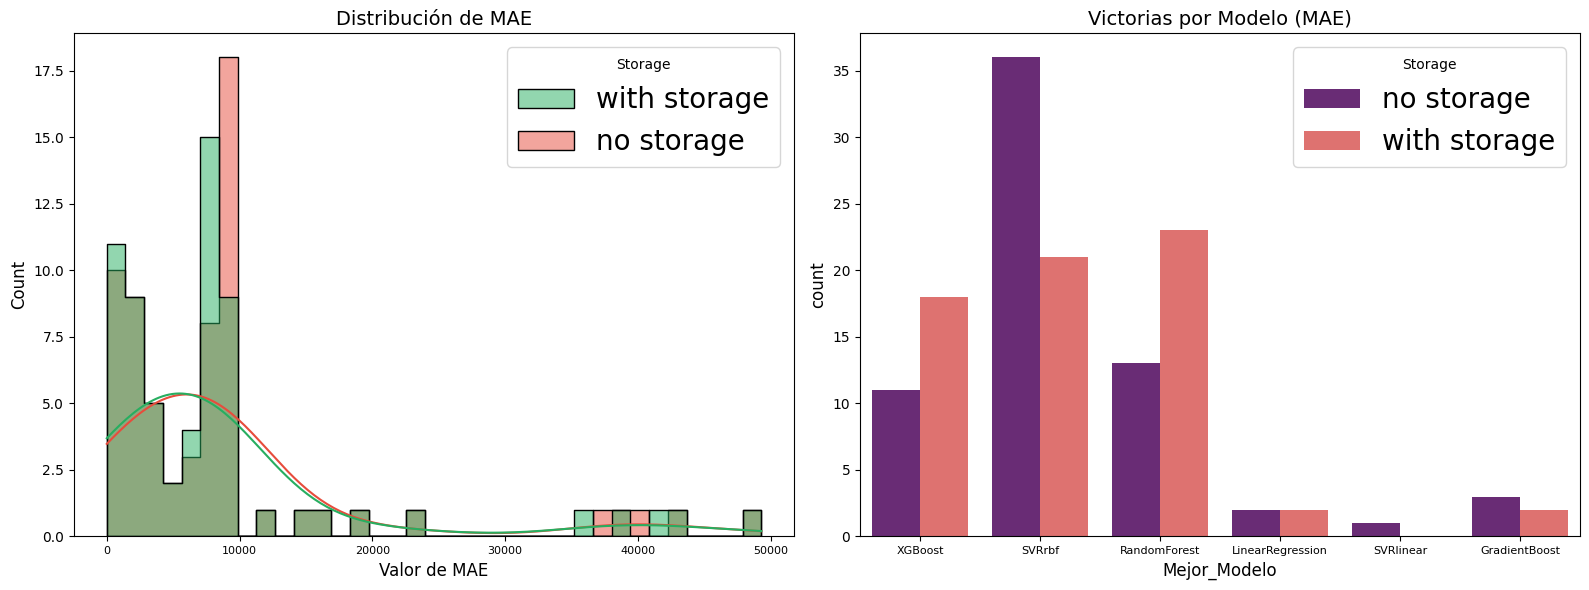


--- Medias por modelo ganador (Criterio: MAE) ---
        Mejor_Modelo       Storage    R2       MAE
0      GradientBoost    no storage  0.12 29,754.47
1      GradientBoost  with storage  0.17 40,535.17
2   LinearRegression    no storage  0.77  1,869.76
3   LinearRegression  with storage  1.00  1,164.61
4       RandomForest    no storage  0.45  8,718.37
5       RandomForest  with storage  0.38  7,323.02
6          SVRlinear    no storage  1.00  1,333.16
7             SVRrbf    no storage -0.25  6,737.65
8             SVRrbf  with storage -0.26  6,290.74
9            XGBoost    no storage  0.39 17,366.87
10           XGBoost  with storage  0.38 13,163.26


In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colores_storage = { 'with storage': '#27ae60', 'no storage': '#e74c3c',}
limite_95 = df_mejores['Valor_Metrica'].quantile(0.99)#Sin outalyers
df_filtrado = df_mejores[df_mejores['Valor_Metrica'] <= limite_95]

sns.histplot(data=df_filtrado, x='Valor_Metrica', hue='Storage',hue_order=['with storage','no storage'], kde=True, 
             element="step", palette=colores_storage, ax=ax1, alpha=0.5,edgecolor = 'black', bins=35)
ax1.set_title(f'Distribución de {METRICA_OBJETIVO.upper()}')
ax1.set_xlabel(f'Valor de {METRICA_OBJETIVO.upper()}')

sns.countplot(data=df_mejores, x='Mejor_Modelo', hue='Storage', palette='magma', ax=ax2)
ax2.set_title(f'Victorias por Modelo ({METRICA_OBJETIVO.upper()})')

plt.tight_layout()
if save:
    plt.savefig(f'../memory/{carpeta}/mejor_mod_sep.pdf')

plt.show()

media_global = df_mejores.groupby(['Mejor_Modelo', 'Storage'])[['R2', 'MAE']].mean().reset_index()
print(f"\n--- Medias por modelo ganador (Criterio: {METRICA_OBJETIVO.upper()}) ---")
print(media_global)
if save:
    media_global.to_csv(f'../memory/{carpeta}/seleccion_sep.csv', index=False)

### Mezclando storage types

In [25]:
resultados_finales = []
for contract, signatures in models_dict.items():
    for signature, datos_firma in signatures.items():
        if datos_firma['size'] < 10: continue
        
        candidatos = []
        for s_type in ['no storage', 'with storage']:
            for m_name in modelos_usados:
                if m_name in datos_firma[s_type]:
                    obj = datos_firma[s_type][m_name]
                    candidatos.append({
                        'Contrato': contract, 'Signature': signature,
                        'Storage_Elegido': s_type, 'Modelo_Elegido': m_name,
                        'R2': obj.r2, 'MAE': obj.mae,
                        'Valor_Metrica': obj.r2 if METRICA_OBJETIVO == 'r2' else obj.mae
                    })
        if candidatos:
            ganador = max(
                candidatos,
                key=lambda m: m['Valor_Metrica'] if METRICA_OBJETIVO == 'r2' else -m['Valor_Metrica']
            )
            resultados_finales.append(ganador)
            
df_maestro = pd.DataFrame(resultados_finales)

In [26]:
# Diccionario de modelos optimizados por contrato y firma
modelos_optimizados = {}

for contract, signatures in models_dict.items():
    modelos_optimizados[contract] = {}
    
    for signature, datos_firma in signatures.items():
        # Saltamos firmas con datos insuficientes o si la llave no existe
        if datos_firma.get('size', 0) < 10: 
            continue
            
        # Lista para comparar todas las opciones (Modelo x Configuración de Storage)
        candidatos = []
        for s_type in ['no storage', 'with storage']:
            # Usamos .get() para evitar KeyErrors si un tipo de storage no tiene modelos
            modelos_en_s = datos_firma.get(s_type, {})
            for m_name in modelos_usados:
                if m_name in modelos_en_s:
                    obj = modelos_en_s[m_name]
                    candidatos.append({
                        'objeto_modelo': obj.model,
                        'nombre_modelo': m_name,
                        'tipo_storage': s_type,
                        'r2': obj.r2,
                        'mae': obj.mae,
                        'valor_Metrica': obj.r2 if METRICA_OBJETIVO == 'r2' else obj.mae,
                        'n_muestras': datos_firma['size']
                    })
        
        if candidatos:
            ganador = max(
                candidatos,
                key=lambda m: m['valor_Metrica'] if METRICA_OBJETIVO == 'r2' else -m['valor_Metrica']
            )                
            modelos_optimizados[contract][signature] = ganador

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


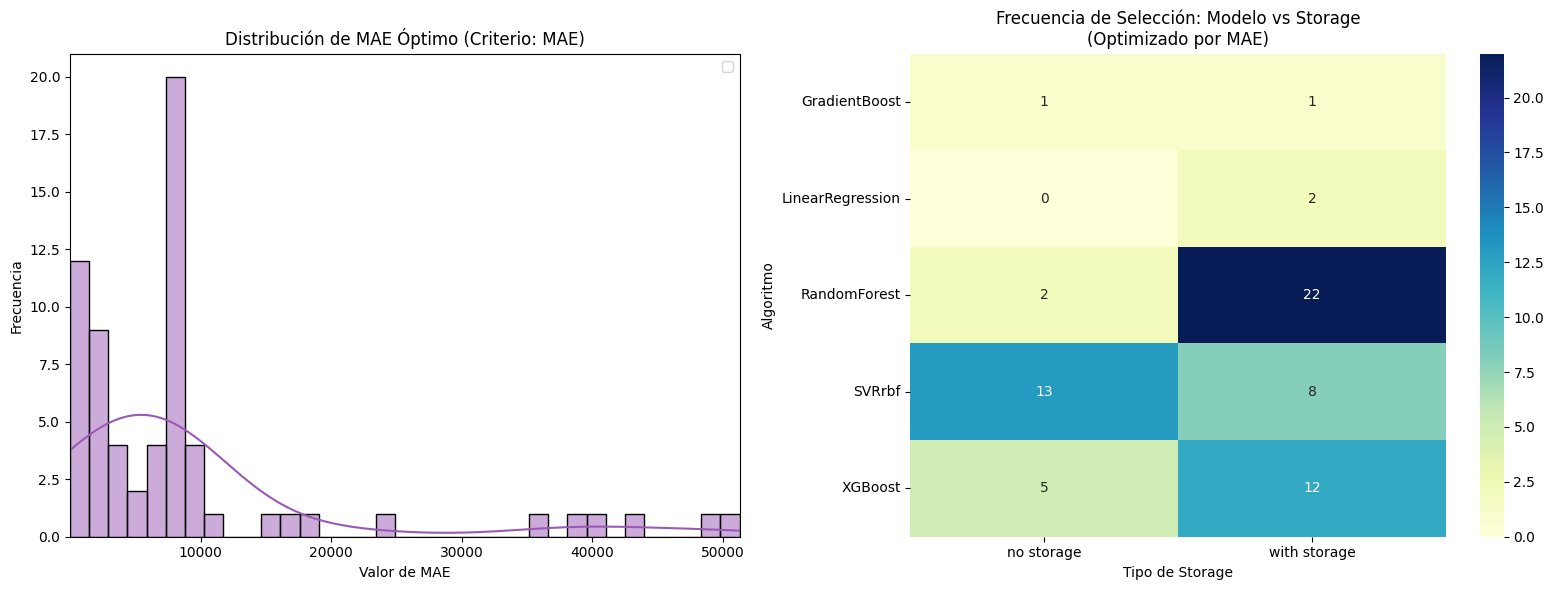

In [27]:
columna_visual = 'R2' if METRICA_OBJETIVO == 'r2' else 'MAE'
df_maestro['Valor_Visual'] = df_maestro[columna_visual].apply(
    lambda x: -0.05 if (METRICA_OBJETIVO == 'r2' and x < -0.05) else x
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rango = (df_maestro['Valor_Visual'].quantile(0.0), df_maestro['Valor_Visual'].quantile(1))
sns.histplot(df_maestro['Valor_Visual'], kde=True, color='#9b59b6', ax=ax1, kde_kws={'clip': rango},bins=35)
ax1.set_xlim(rango)
ax1.set_ylabel('Frecuencia')
media_sistema = df_maestro[columna_visual].mean()

ax1.set_title(f'Distribución de {columna_visual} Óptimo (Criterio: {METRICA_OBJETIVO.upper()})')
ax1.set_xlabel(f'Valor de {columna_visual}')
ax1.legend()

pivot_count = df_maestro.groupby(['Modelo_Elegido', 'Storage_Elegido']).size().unstack(fill_value=0)
sns.heatmap(pivot_count, annot=True, fmt='d', cmap='YlGnBu', ax=ax2)
ax2.set_title(f'Frecuencia de Selección: Modelo vs Storage\n(Optimizado por {METRICA_OBJETIVO.upper()})')
ax2.set_xlabel('Tipo de Storage')
ax2.set_ylabel('Algoritmo')

plt.tight_layout()

if(save): 
    plt.savefig(f'../memory/{carpeta}/distrib_mejorMod_Mix_{METRICA_OBJETIVO}.pdf')
    
plt.show()

In [28]:
print("\n" + "="*30)
print(f" RESUMEN DE SELECCIÓN (CRITERIO: {METRICA_OBJETIVO.upper()}) ")
print("="*30)

conteo_modelos = df_maestro['Modelo_Elegido'].value_counts()
print("\nDistribución por MODELO:")
print(conteo_modelos)

conteo_storage = df_maestro['Storage_Elegido'].value_counts()
print("\nDistribución por STORAGE:")
print(conteo_storage)

r2_medio_sistema = df_maestro['R2'].mean()
mae_medio_sistema = df_maestro['MAE'].mean()

print("\n--- Desempeño Medio del Sistema ---")
print(f"R² Medio Global:  {r2_medio_sistema:.4f}")
print(f"MAE Medio Global: {mae_medio_sistema:.4f}")

valor_metrica_optimizada = df_maestro['Valor_Metrica'].mean()
print(f"\nPromedio de la métrica objetivo ({METRICA_OBJETIVO.upper()}): {valor_metrica_optimizada:.4f}")

if save:
    if(save): 
        path_csv = f'../memory/{carpeta}/mejor_modelo_mix_{METRICA_OBJETIVO}.csv'
        df_maestro.to_csv(path_csv, index=False)
    
    # Opcional: Guardar también las estadísticas en un archivo de texto
    with open(f'../memory/{carpeta}/resumen_seleccion_{METRICA_OBJETIVO}.txt', 'w') as f:
        f.write(f"RESUMEN DE SELECCIÓN - CRITERIO: {METRICA_OBJETIVO.upper()}\n")
        f.write("="*40 + "\n")
        f.write(f"Distribución por MODELO:\n{conteo_modelos.to_string()}\n\n")
        f.write(f"Distribución por STORAGE:\n{conteo_storage.to_string()}\n\n")
        f.write(f"R2 Medio Global: {r2_medio_sistema:.4f}\n")
        f.write(f"MAE Medio Global: {mae_medio_sistema:.4f}\n")
        f.write(f"Métrica Objetivo ({METRICA_OBJETIVO.upper()}): {valor_metrica_optimizada:.4f}\n")
    
    print(f"\n[INFO] Resultados y resumen exportados a ../memory/{carpeta}/")


 RESUMEN DE SELECCIÓN (CRITERIO: MAE) 

Distribución por MODELO:
Modelo_Elegido
RandomForest        24
SVRrbf              21
XGBoost             17
LinearRegression     2
GradientBoost        2
Name: count, dtype: int64

Distribución por STORAGE:
Storage_Elegido
with storage    45
no storage      21
Name: count, dtype: int64

--- Desempeño Medio del Sistema ---
R² Medio Global:  0.1918
MAE Medio Global: 9376.7314

Promedio de la métrica objetivo (MAE): 9376.7314


## Experimentos

In [33]:
SIGNATURES_ERC20 = { 
    '0x095ea7b3': 'approve',
    '0xa9059cbb': 'transfer',
    '0x23b872dd': 'transferFrom',
    '0xd505accf': 'permit',
    '0x42966c68': 'burn',
    '0x79cc6790': 'burnFrom',
    '0x40c10f19': 'mint',
    '0xa457c2d7': 'decreaseAllowance',
    '0x39509351': 'increaseAllowance',
    '0x2f4f21e2': 'depositFor',
    '0x205c2878': 'withdrawTo'
}

### Code

In [31]:
MIN_SIZE = 10000
R2_LIMIT = 0.8

In [32]:
df_maestro['Grupo_Signature'] = df_maestro['Signature'].map(SIGNATURES_ERC20).fillna('OTRAS')
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

resumen_especial = df_maestro.groupby('Grupo_Signature').agg({
    'Signature': 'count',                        
    'Modelo_Elegido': lambda x: x.mode()[0],     
    'Storage_Elegido': lambda x: x.mode()[0],    
    'R2': 'mean',                                 
    'MAE': 'mean'                                
}).rename(columns={
    'Signature': 'Num_Modelos', 
    'R2': 'R2_Promedio',
    'MAE': 'MAE_Promedio',
})

resumen_especial = resumen_especial.sort_index(ascending=True)

if save: 
    path_csv = f'../memory/{carpeta}/mejor_modelo_mix_signatureTypes.csv'
    # Usamos index=True porque 'Grupo_Signature' (Nombre de función) es el índice
    resumen_especial.to_csv(path_csv, index=True)

print("\n" + "="*80)
print("RESUMEN DE DESEMPEÑO POR SIGNATURE (ESPECIALES VS OTRAS)")
print("="*80)
print(resumen_especial)


RESUMEN DE DESEMPEÑO POR SIGNATURE (ESPECIALES VS OTRAS)
                 Num_Modelos Modelo_Elegido Storage_Elegido  R2_Promedio  MAE_Promedio
Grupo_Signature                                                                       
OTRAS                     32         SVRrbf    with storage     0.209092  11442.042705
approve                    7        XGBoost    with storage     0.657958   2354.726554
transfer                  25   RandomForest    with storage     0.012661   9364.201857
transferFrom               2   RandomForest    with storage     0.521503   1065.386586


#### Mejores Modelos

In [33]:
n_signatures = 0
n_erc20_signatures = 0
erc20_great_values = 0
_signatures_erc20 = set()
r2_values = []
r2_values_erc20 = []
_set = set()

# Iteramos sobre los modelos que ya fueron filtrados y optimizados
for contract, signatures in modelos_optimizados.items():
    for signature, ganador in signatures.items():
        # 'ganador' ya es el diccionario con el mejor modelo {'r2': ..., 'objeto_modelo': ..., etc.}
        
        r2 = ganador['r2']
        n_signatures += 1
        r2_values.append(r2)

        # Si el mejor modelo supera el límite, lo guardamos para el análisis detallado
        if r2 > R2_LIMIT:
            _set.add((contract, signature))

        # Comprobación de interfaz ERC20
        if str(signature).lower() in SIGNATURES_ERC20:
            n_erc20_signatures += 1
            r2_values_erc20.append(r2)

            if r2 > R2_LIMIT:
                erc20_great_values += 1
                # Guardamos info legible: "NombreFuncion (0x...) en Contrato"
                nombre_f = SIGNATURES_ERC20[signature.lower()]
                _signatures_erc20.add(f"{nombre_f} ({signature}) en {contract}")

print(f"Nº total de signaturas procesadas: {n_signatures}")
print(f"Nº de signaturas que pertenecen a la interfaz ERC20: {n_erc20_signatures}")
print(f"Nº de signaturas ERC20 con R2 > {R2_LIMIT}: {erc20_great_values}")
print("\nDetalle de firmas ERC20 destacadas:")
for item in sorted(_signatures_erc20):
    print(f" - {item}")

Nº total de signaturas procesadas: 66
Nº de signaturas que pertenecen a la interfaz ERC20: 34
Nº de signaturas ERC20 con R2 > 0.8: 3

Detalle de firmas ERC20 destacadas:
 - approve (0x095ea7b3) en 0xdac17f958d2ee523a2206206994597c13d831ec7
 - transfer (0xa9059cbb) en 0xdac17f958d2ee523a2206206994597c13d831ec7
 - transferFrom (0x23b872dd) en 0xdac17f958d2ee523a2206206994597c13d831ec7


#### Pesos de las variables:

In [34]:
print(f'Modelos con r2 mayor a 0.8: {len(_set)}')

Modelos con r2 mayor a 0.8: 8


In [35]:
for contract, signature in _set:
    ganador = modelos_optimizados.get(contract, {}).get(signature)
    if not ganador:
        print(f"Saltando ['{contract}']['{signature}']: No tiene modelo optimizado.")
        continue
    modelo_final = ganador['objeto_modelo']
    s_type_elegido = ganador['tipo_storage']
    m_nombre_elegido = ganador['nombre_modelo']
    nombre_funcion = SIGNATURES_ERC20.get(signature, "OTRAS")
    tipo_tecnico = modelo_final.__class__.__name__
    datos_originales = models_dict[contract][signature]
    print(f"['{contract}']['{signature}'] ({nombre_funcion})")
    print(f"Modelo: {s_type_elegido} | Algoritmo: {m_nombre_elegido} ({tipo_tecnico})")
    if s_type_elegido == "with storage":
        column_names = datos_originales["X_test"].columns
    else:
        storage_cols = datos_originales.get("storage info", [])
        column_names = datos_originales["X_test"].drop(columns=storage_cols, errors="ignore").columns
    print(f"R2 = {ganador['r2']:.4f}")
    print(f"MAE = {ganador['mae']:.2f}")

    if hasattr(modelo_final, 'coef_'):
        # Caso Lineal: Extraemos coeficientes
        feature_importances = modelo_final.coef_
        # Si es una matriz (ej. Ridge/Lasso con múltiples targets), aplanamos
        if hasattr(feature_importances, 'ndim') and feature_importances.ndim > 1:
            feature_importances = feature_importances[0]
            
    elif hasattr(modelo_final, 'feature_importances_'):
        # Caso Árboles: Extraemos importancia Gini
        feature_importances = modelo_final.feature_importances_
    
    if feature_importances is not None:
        print("Pesos / Coeficientes:")
        # Ordenamos por VALOR ABSOLUTO (importancia real), pero mostramos el signo original
        importancias = sorted(
            zip(column_names, feature_importances),
            key=lambda x: abs(x[1]), 
            reverse=True
        )
        for column, val in importancias:
            # Mostramos 6 decimales y el signo
            print(f"\t{column}: {val:+.6f}")
    else:
        print("Pesos: No disponibles para este tipo de modelo.")

    print("-" * 70)

['0xdac17f958d2ee523a2206206994597c13d831ec7']['0xa9059cbb'] (transfer)
Modelo: with storage | Algoritmo: RandomForest (RandomForestRegressor)
R2 = 0.9420
MAE = 615.74
Pesos / Coeficientes:
	strgslot_6: +0.277637
	strgslot_5: +0.230316
	strgslot_7: +0.219861
	strgval_7: +0.114236
	strgval_6: +0.083189
	strgval_5: +0.061065
	storage_is_missing: +0.009731
	uint256__value: +0.002928
	strg_len: +0.000748
	_value_iszero: +0.000183
	input_len: +0.000106
	strgbigval_1: +0.000000
	strgbigval_2: +0.000000
	strgbigval_3: +0.000000
	strgbigval_4: +0.000000
	strgbigval_5: +0.000000
	strgbigval_6: +0.000000
	strgbigval_7: +0.000000
	strgslot_1: +0.000000
	strgslot_2: +0.000000
	strgslot_3: +0.000000
	strgslot_4: +0.000000
	strgval_1: +0.000000
	strgval_2: +0.000000
	strgval_3: +0.000000
	strgval_4: +0.000000
----------------------------------------------------------------------
['0xc662c410c0ecf747543f5ba90660f6abebd9c8c4']['0x77552641'] (OTRAS)
Modelo: no storage | Algoritmo: RandomForest (RandomF

## Análisis de pesos (Linear Regresion)

Si se quiere estudiar modelos lineales

In [128]:
model_name = 'LinearRegression'
s_type = 'with storage'

In [135]:
contract = '0x5e4e65926ba27467555eb562121fac00d24e9dd2'
signature = '0xd0f89344' #OTRAS

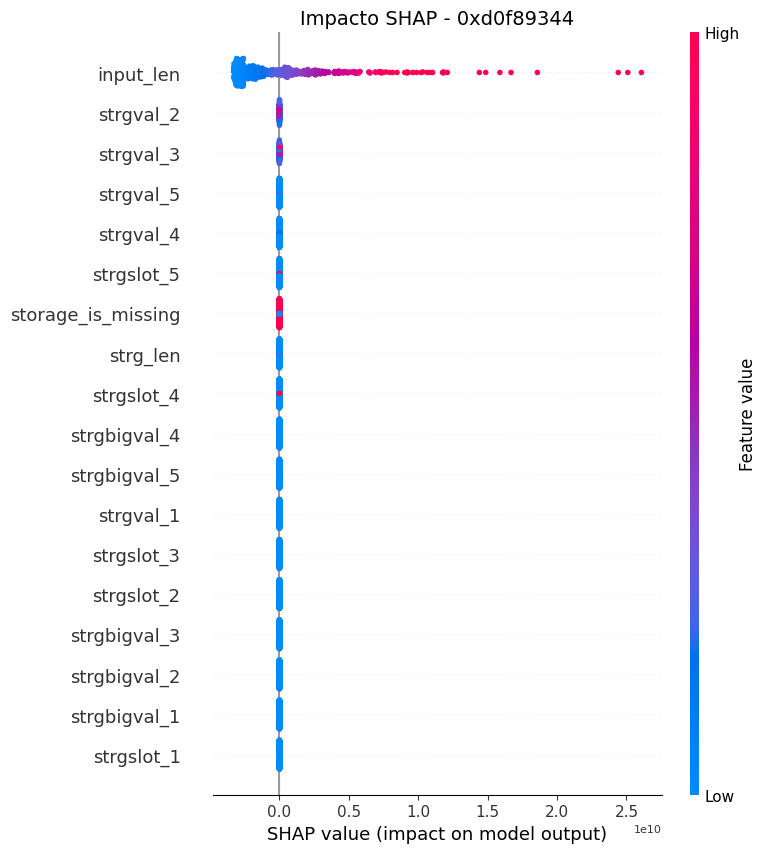

In [136]:
ganador = modelos_optimizados[contract][signature]
modelo = ganador['objeto_modelo']
datosX = models_dict[contract][signature]["X_test"]

explainer = shap.LinearExplainer(modelo, datosX)
shap_values = explainer.shap_values(datosX)

plt.title(f"Impacto SHAP - {signature}")
shap.summary_plot(shap_values, datosX)

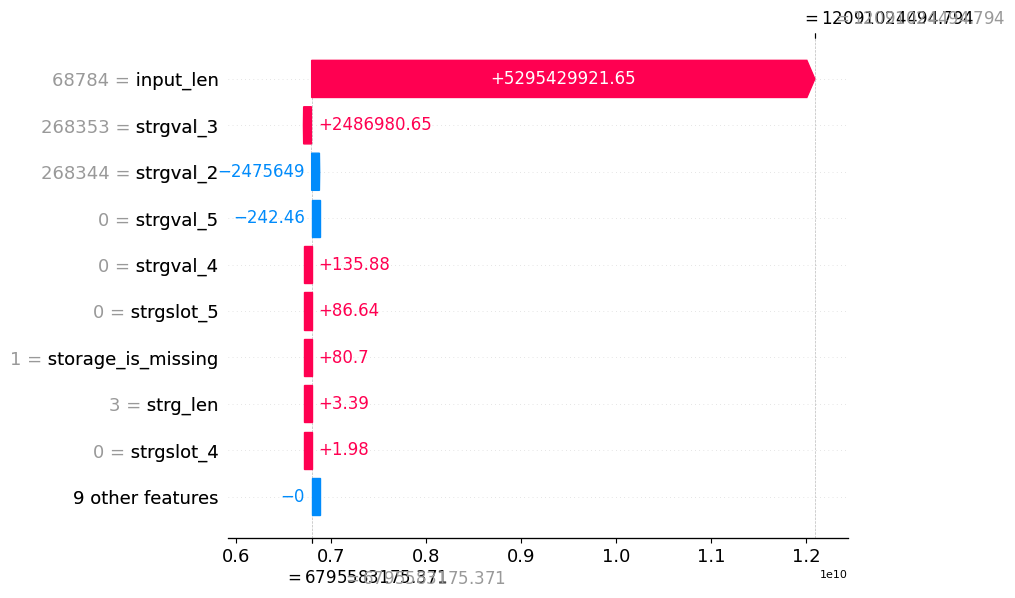

In [137]:
shap_values_objeto = explainer(datosX)
shap.plots.waterfall(shap_values_objeto[0])

## Análisis de pesos (RandomForest)

In [29]:
model_name = 'RandomForest'
s_type = 'with storage'

In [30]:
contract = '0xdac17f958d2ee523a2206206994597c13d831ec7'
signature = '0xa9059cbb' #transfer

### Visualización del árbol

Visualizando árbol para el mejor modelo: RandomForest


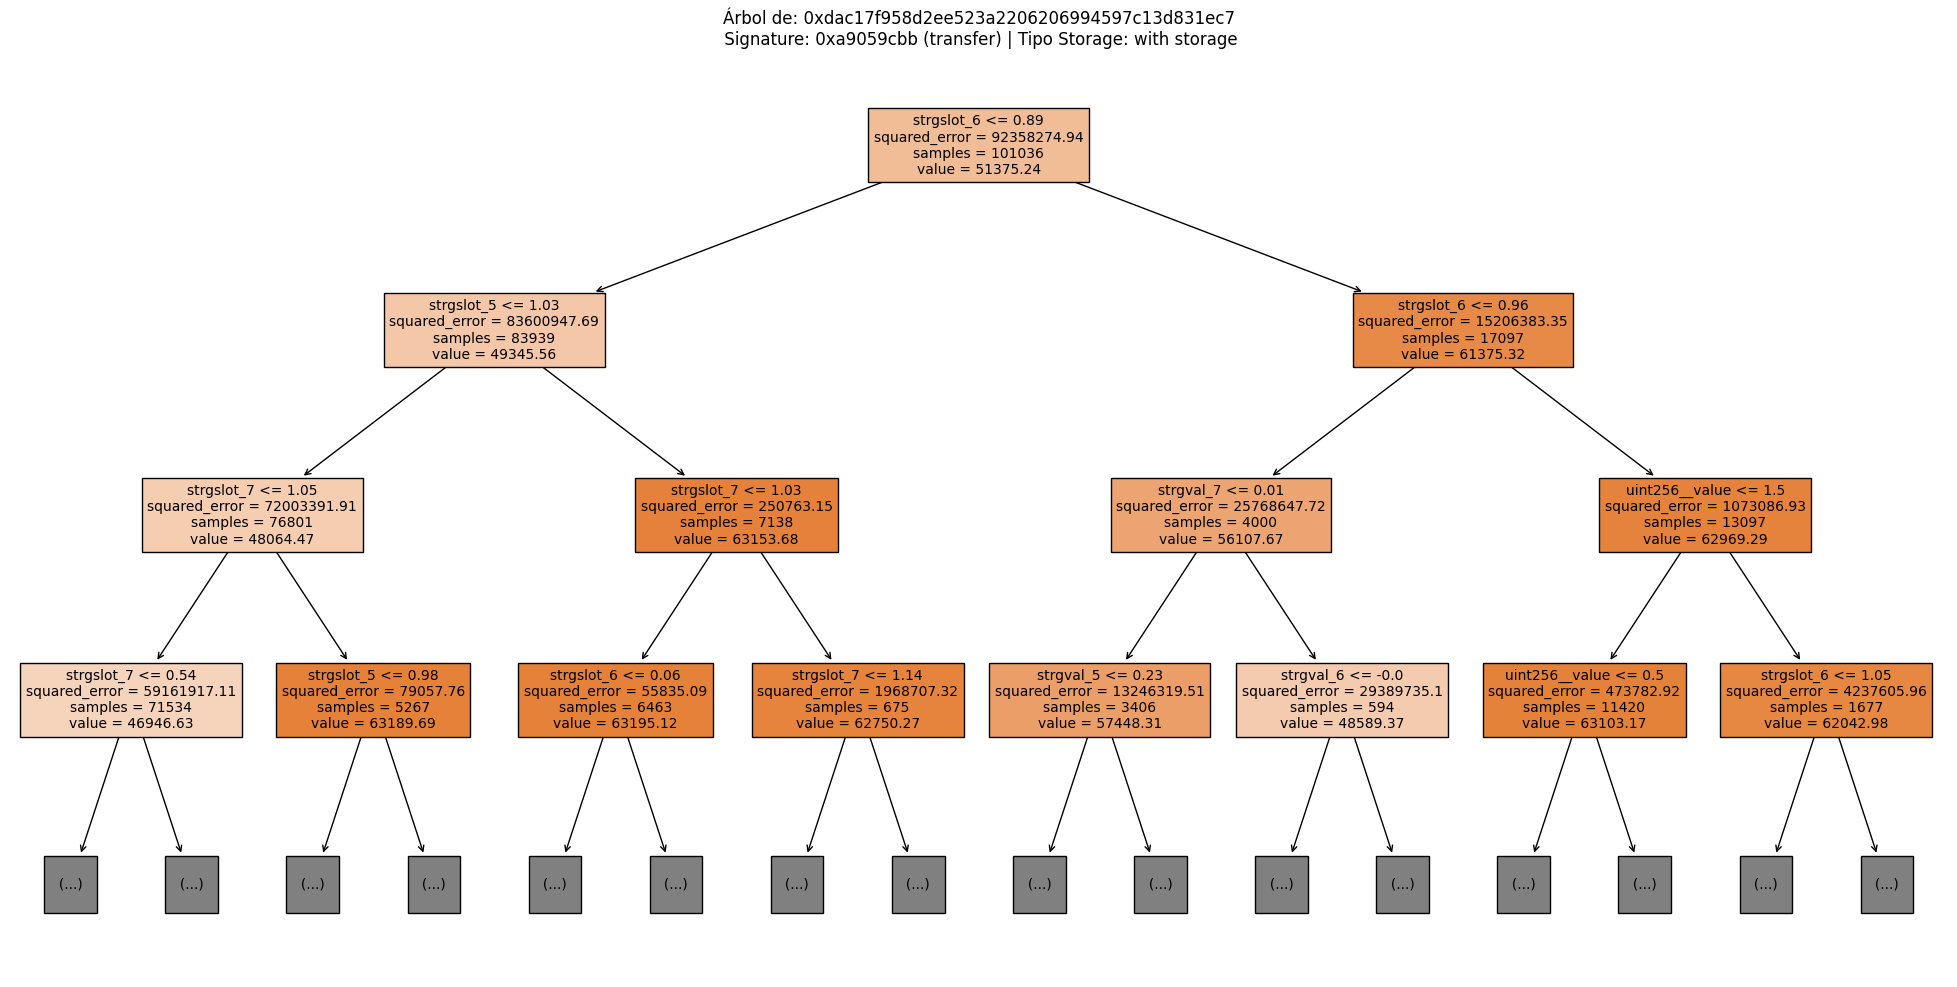

In [27]:
ganador = modelos_optimizados[contract][signature]
modelo_final = ganador['objeto_modelo']
datos_originales = models_dict[contract][signature]
datosX = datos_originales["X_test"]

if ganador['nombre_modelo'] == 'RandomForest':
    print(f"Visualizando árbol para el mejor modelo: {ganador['nombre_modelo']}")
    
    if ganador['tipo_storage'] == "with storage":
        feature_names = datosX.columns
    else:
        storage_cols = datos_originales.get("storage info", [])
        feature_names = datosX.drop(columns=storage_cols, errors="ignore").columns

    plt.figure(figsize=(25, 12))
    tree.plot_tree(
        modelo_final.estimators_[0], # El primer árbol del bosque ganador
        feature_names=feature_names,
        filled=True,
        max_depth=3,
        fontsize=10,
        precision=2
    )
    
    plt.title(f"Árbol de: {contract}\n Signature: {signature} ({SIGNATURES_ERC20.get(signature, signature)}) | Tipo Storage: {ganador['tipo_storage']}")
    
    if save:
        plt.savefig(f'../memory/{carpeta}/arbol_ganador_{signature}.pdf', bbox_inches='tight')
    plt.show()
else:
    print(f"El modelo ganador es {ganador['nombre_modelo']}, no se puede visualizar como árbol de decisión.")

Generando SHAP para: RandomForest (with storage)


NameError: name 'SIGNATURES_ERC20' is not defined

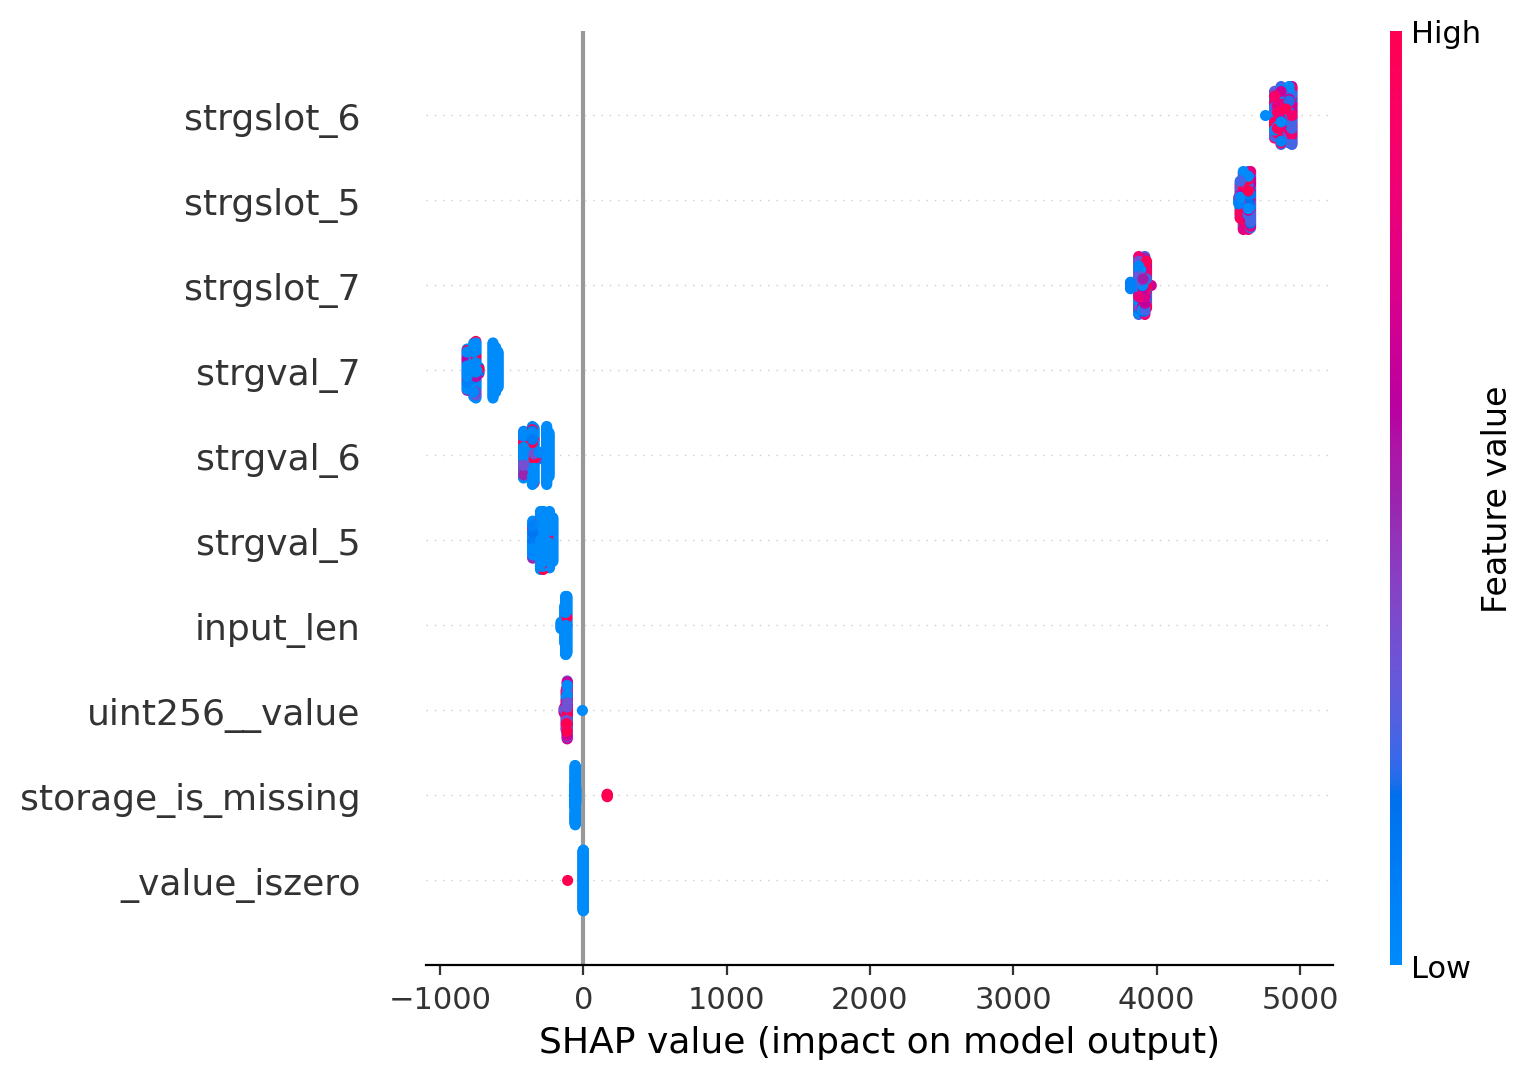

In [31]:
ganador = modelos_optimizados[contract][signature]
modelo_final = ganador['objeto_modelo']
datos_originales = models_dict[contract][signature]

X_test = datos_originales["X_test"]
if ganador['tipo_storage'] != "with storage":
    storage_cols = datos_originales.get("storage info", [])
    X_test = X_test.drop(columns=storage_cols, errors="ignore")

X_shap = X_test.sample(
    n=min(200, len(X_test)), 
    random_state=42
)

print(f"Generando SHAP para: {ganador['nombre_modelo']} ({ganador['tipo_storage']})")

if hasattr(modelo_final, 'coef_'):
    explainer = shap.LinearExplainer(modelo_final, X_shap)
    shap_values = explainer.shap_values(X_shap)
else:
    explainer = shap.TreeExplainer(modelo_final)
    shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list) and len(shap_values) > 0:
    shap_values_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_to_plot = shap_values

plt.figure(figsize=(8, 6), dpi=200) 

shap.summary_plot(
    shap_values_to_plot,
    X_shap, 
    max_display=10, 
    show=False
)

nombre_funcion = SIGNATURES_ERC20.get(signature, signature)
plt.title(f"Top 10 Variables - Impacto SHAP\n{nombre_funcion} ({ganador['nombre_modelo']})", 
          fontsize=14, pad=15)
plt.xlabel("Impacto SHAP (Contribución al Gas)", fontsize=12)

plt.tight_layout()
plt.show()

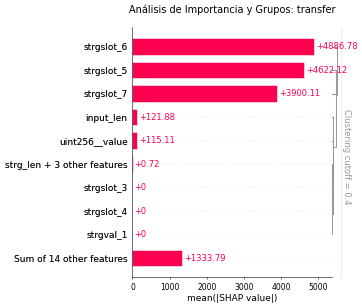

In [34]:
plt.figure(figsize=(16, 12), dpi=50)

shap_explanation = explainer(X_shap)
clustering = shap.utils.hclust(X_shap)

shap.plots.bar(
    shap_explanation,
    clustering=clustering,
    clustering_cutoff=0.4, 
    max_display=10,
    show=False
)

plt.subplots_adjust(right=0.8, left=0.3)

nombre_f = SIGNATURES_ERC20.get(signature, signature)
plt.title(f"Análisis de Importancia y Grupos: {nombre_f}", fontsize=14, pad=20)

if save:
    plt.savefig(f'../memory/{carpeta}/shap_clustering_espaciado.pdf', bbox_inches='tight')

plt.show()

### Visualización para una transacción concreta del contrato-signature concreto

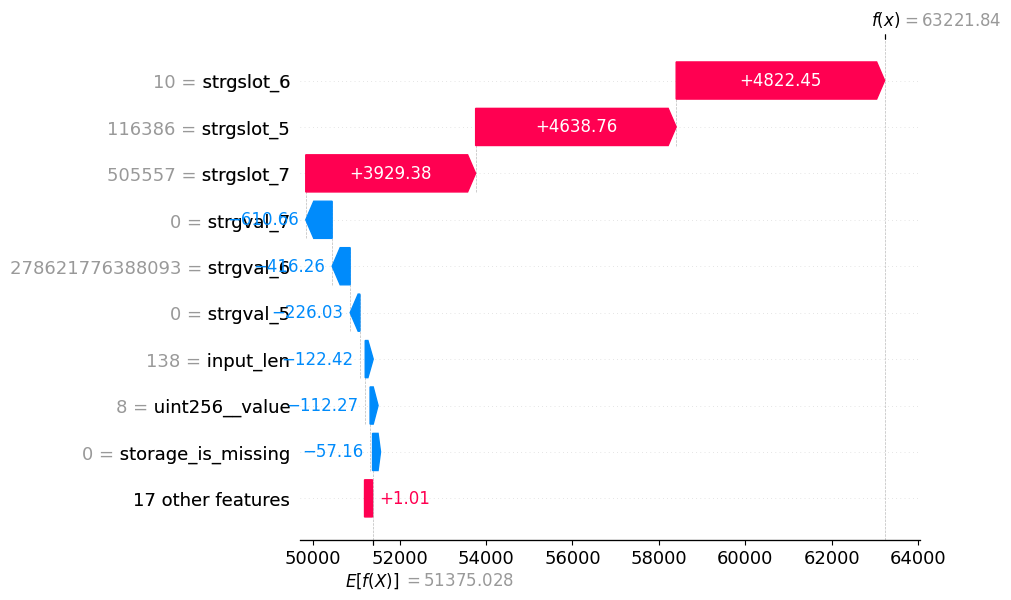

In [35]:
# Explicación individual
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)
if(save): 
    plt.savefig(f'../memory/{carpeta}/shap_una_transaccion.pdf')

### Análisis de toma de decisiones

Cuenta apariciones valores más altos.

In [39]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
logging.getLogger("joblib").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

conteo_liderazgo_storage = 0
total_modelos_procesados = 0
importancia_relativa_acumulada_storage = 0.0
total_importancia_relativa_global = 0.0  

for contract, funciones in modelos_optimizados.items():
    for signature, ganador in funciones.items():
        
        modelo_final = ganador.get('objeto_modelo')
        s_type_elegido = ganador.get('tipo_storage')
        
        if not modelo_final or contract not in models_dict:
            continue
            
        datos = models_dict[contract][signature]
        X_test = datos["X_test"].copy().reset_index(drop=True)
        y_test = datos["y_test"].copy().reset_index(drop=True)
        
        # 1. Definir columnas según el tipo de storage
        if s_type_elegido == "with storage":
            X_eval = X_test
        else:
            storage_cols = datos.get("storage info", [])
            X_eval = X_test.drop(columns=storage_cols, errors="ignore")
        
        column_names = X_eval.columns

        pesos = None
        if hasattr(modelo_final, 'coef_'):
            pesos = np.abs(modelo_final.coef_)
            if pesos.ndim > 1: pesos = pesos[0]
        elif hasattr(modelo_final, 'feature_importances_'):
            pesos = modelo_final.feature_importances_

        if pesos is None:
            try:
                r = permutation_importance(
                    modelo_final, X_eval, y_test, 
                    n_repeats=5, random_state=42, n_jobs=-1
                )
                pesos = np.abs(r.importances_mean)
            except Exception as e:
                print(f"Saltando {contract}-{signature} por error: {e}")
                continue

        if pesos is not None and len(pesos) > 0:
            suma_pesos_modelo = np.sum(pesos)
            if suma_pesos_modelo == 0: continue 
            
            pesos_relativos = pesos / suma_pesos_modelo
            
            importancias = list(zip(column_names, pesos_relativos))
            importancias_ordenadas = sorted(importancias, key=lambda x: x[1], reverse=True)
            
            top_var = importancias_ordenadas[0][0].lower()
            if "strg" in top_var or "storage" in top_var:
                conteo_liderazgo_storage += 1
            for col, p_rel in importancias:
                total_importancia_relativa_global += p_rel
                if "strg" in col.lower() or "storage" in col.lower():
                    importancia_relativa_acumulada_storage += p_rel
            
            total_modelos_procesados += 1

warnings.resetwarnings()

print("=" * 60)
print(f"ANÁLISIS DE IMPORTANCIA (N={total_modelos_procesados} modelos)")
print("-" * 60)
print(f"1. LIDERAZGO (Top 1):")
print(f"   Modelos donde 'storage' es la variable principal: {conteo_liderazgo_storage}")
print(f"   Porcentaje de liderazgo: {(conteo_liderazgo_storage/total_modelos_procesados)*100:.2f}%")
print("-" * 60)
print(f"2. INFLUENCIA PONDERADA (Peso Relativo Acumulado):")
influencia_total = (importancia_relativa_acumulada_storage / total_importancia_relativa_global) * 100
print(f"   Peso real del storage en el total de decisiones: {influencia_total:.2f}%")
print("=" * 60)

ANÁLISIS DE IMPORTANCIA (N=50 modelos)
------------------------------------------------------------
1. LIDERAZGO (Top 1):
   Modelos donde 'storage' es la variable principal: 23
   Porcentaje de liderazgo: 46.00%
------------------------------------------------------------
2. INFLUENCIA PONDERADA (Peso Relativo Acumulado):
   Peso real del storage en el total de decisiones: 52.20%
